<img style="float: center;" src='https://github.com/spacetelescope/jwst-pipeline-notebooks/raw/main/_static/stsci_header.png' alt="stsci_logo" width="900px"/> 

# NIRCam Wide Field Slitless Spectroscopy (WFSS) Pipeline Notebook

**Authors**: B. Hilbert, R. Plesha<br>
**Last Updated**: Aug 20, 2026<br>
**Pipeline Version**: 3.0.0 (Build 13.0)

# **Purpose**:

This notebook provides a framework for processing generic Near-Infrared Camera (NIRCam) wide field slitless spectroscopy (WFSS) data through the James Webb Space Telescope (JWST) pipeline. Data from a single proposal and observation ID is assumed to be located in one observation folder according to paths set up below. It should not be necessary to edit any cells other than in the [Configuration](#1.-Configuration) section unless modifying the standard pipeline processing options. 

**Data**:
This example uses data from the [Program ID 1345](https://www.stsci.edu/jwst/science-execution/program-information?program=1345) observation 012 (PI: Finkelstein). The observations use the F356W and F115W [NIRCam filters](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-filters) and both the GRISMR and GRISMC [NIRCam grisms](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-grisms)

In this example notebook we will only look at the F356W data, as the F115W data from the shortwave channel is not used in the WFSS data reduction and calibration. A [NIRCam WFSS observation sequence](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-observing-strategies/nircam-wfss-recommended-strategies) typically consists of dispersed exposures using a grism followed by a direct image and out of field images in the same blocking filter to help identify the sources in the field. If the second grism is used, the dispersed/direct/out of field pattern of exposures is then repeated. In Observation 12 of program 1345, the exposure sequence follows the pattern: GRISMR dithers -> direct image -> out of field -> GRISMC dithers -> direct image -> out of field.

Example input data to use will be downloaded automatically unless disabled by the `dodownload` parameter (i.e., to use local files instead).

**JWST pipeline version and CRDS context**: 
This notebook was written for the calibration pipeline version given above. The JWST Calibration Reference Data System (CRDS) context used is associated with the pipeline version as listed [here](https://jwst-crds.stsci.edu/display_build_contexts/). If you use different pipeline version or CRDS context, please read the relevant release notes ([here for pipeline](https://github.com/spacetelescope/jwst/releases), [here for CRDS](https://jwst-crds.stsci.edu/display_context_history/)) for possibly relevant changes. The results of this notebook may differ from the products hosted on the [MAST archive](https://mast.stsci.edu/search/ui/#/jwst) depending on the pipeline version and CRDS context you are using.

**Updates**:
This notebook is regularly updated as improvements are made to the pipeline. Find the most up to date version of this notebook at: https://github.com/spacetelescope/jwst-pipeline-notebooks/

**Recent Changes**:<br>
XXX XX, 2026: original notebook released<br>

**Future Updates**:<br>
- In pipeline version 3.2, the extract-1D and photom steps will be reversed. Update documentation for this.
- In pipeline version 3.2, full paths to the i2d, segm, and cat.ecsv files in spec2 association files will be supported. Update association file creation cell and associated documentation. Remove os.chdir calls in the cell that calls spec2.
- In pipeline version 3.2, the bug where the user-supplied output directory for spec3 products is ignored will be corrected. Remove the os.chdir calls in the cell that calls spec3.
- The bug where sources that are present on both detectors lead to NaNs in the c1d file is being worked on. Once this is fixed, update the text around the figure showing the spec3 results.

<hr style="border:1px solid gray"> </hr>

## Table of Contents
1. [Configuration](#1.-Configuration) 
2. [Package Imports](#2.-Package-Imports)
3. [Directory Setup](#3.-Directory-Setup)
4. [Demo Mode Setup (Data Download)](#4.-Demo-Mode-Setup-(Data-Download))
5. [Detector 1 Pipeline](#5.-Detector1-Pipeline)
6. [Image2 Pipeline](#6.-Image2-Pipeline)
7. [Image3 Pipeline](#7.-Image3-Pipeline)
8. [Visualize Image3 Output Products](#8.-Visualize-Image3-Output-Products)
9. [Spec2 Pipeline](#9.-Spec2-Pipeline)
10. [Understanding Spec2 Output Products](#10.-Understanding-Spec2-Output-Products)
11. [Spec3 Pipeline](#11.-Spec3-Pipeline)
12. [Understanding Spec3 Output Products](#12.-Understanding-Spec3-Output-Products)

<hr style="border:1px solid gray"> </hr>

## 1. Configuration
------------------
Set basic configuration for running notebook.

#### Install dependencies and parameters

To make sure that the pipeline version is compatabile with the steps
discussed below and the required dependencies and packages are installed,
you can create a fresh conda environment and install the provided
`requirements.txt` file:
```
conda create -n nrc_wfss python=3.13
conda activate nrc_wfss
pip install -r requirements.txt
```

Set the basic parameters to use with this notebook. These will affect
what data is used, where data is located (if already in disk), names of any outputs, and
pipeline modules run in this data. The list of parameters are:

* demo_mode
* sci_dir (directory where the data are / will be)
* dodownload (download the data locally)
* pipeline modules:
  * dodet1 (run detector1)
  * doimage2 (run image2)
  * doimage3 (run image3)
  * dospec2 (run spec2)
  * dospec3 (run spec3)
* doviz (show visualizations of the data within the notebook)
* program (proposal ID of your data for the level 3 association files)
* sci_observtn (observation of your data for level 3 the association files)

In [1]:
# Basic import necessary for configuration
import os

# Establish what directory we're currently working in
cwd = os.getcwd()

<div class="alert alert-block alert-warning">
Adjust any parameters in the cell directly below this before running to ensure <code>demo_mode</code> runs correctly.
</div>

Set <code>demo_mode = True</code> to run in demonstration mode. In this mode this notebook will download example data from the Barbara A.
Mikulski Archive for Space Telescopes (MAST) and process everything through the pipeline. This will all happen in a local directory unless modified in the configuration below (variable `data_dir`).

In [2]:
# -----------------------------Demo Mode---------------------------------
# Use the provided example for demonstration purposes
demo_mode = True

if demo_mode:
    program = '01345'
    sci_observtn = '012'

    # Create a directory for the data called "nrc_wfss_demo_data" 
    # located in the directory you are currently in
    data_dir = os.path.join(cwd, 'nrc_wfss_demo_data')
    sci_dir = os.path.join(data_dir, f"PID{program}/obs{sci_observtn}")

    print(f'Running in demonstration mode using example data from program {program} obs{sci_observtn}!')
    print(f'Data located in: {sci_dir}')

    # To download the demo data
    dodownload = True

Running in demonstration mode using example data from program 01345 obs012!
Data located in: /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012


Set <code>demo_mode = False</code> if you want to process your own data that has already been downloaded. To do so, in the cell below, provide the program ID in the `program` variable, the observation ID in the `sci_observtn` variable, and the top path level location of the data in the `sci_dir` variable. The notebook expects that the `uncal` files are in a directory under `sci_dir` called `uncal`.

If you would like to additionally download the data for a specific program through this notebook, you can additionally set the `dodownload` variable to True below, and the data will be downloaded to the provided `sci_dir` directory.

In [3]:
# --------------------------User Mode Directories------------------------
# If demo_mode = False, look for user data in these paths
if not demo_mode:
    # Set directory paths for processing specific data; these will need
    # to be changed to your local directory setup (below are given as
    # examples)
    user_home_dir = os.path.expanduser('~')

    # Point to where science observation data are
    # Assumes uncalibrated data in sci_dir/uncal/ and results in stage1,
    # stage2, stage3 directories
    program = '01345' # modify this to your specific program
    sci_observtn = '012' # modify this to your specific program
    sci_dir = os.path.join(user_home_dir, f'nrc_wfss_demo_data/PID{program}/obs{sci_observtn}/')

    # If you would like to download your data using astroquery, set dodownload below
    # to True, and don't skip the Demo Mode Setup section
    dodownload = False  
                        
    print(f'Running using user input data from: {sci_dir} for program {program} obs{sci_observtn}')

Set any of the variables below to be True (do the processing) or False (don't do the processing). To run this notebook from start to completion, it is expected that the output products from each of the stages below are located in the appropriate directories as set in [#3. Directory Setup](#3.-Directory-Setup). If these output products do not exist, any of the later stages of the pipeline may not work as intended. 

In [4]:
# --------------------------Set Processing Steps--------------------------
# Individual pipeline stages can be turned on/off here.  Note that a later
# stage won't be able to run unless data products have already been
# produced from the prior stage.

# Visualization of products within the notebook
doviz = True # Visualize outputs

# Science processing
dodet1 = True    # calwebb_detector1; files saved in "stage1" directory
doimage2 = True  # calwebb_image2; files saved in "stage2_img" directory
doimage3 = True  # calwebb_image3; files saved in "stage3_img" directory
dospec2 = True   # calwebb_spec2; files saved in "stage2_spec" directory
dospec3 = True   # calwebb_spec3; files saved in "stage3_spec" directory

### Set CRDS context and server
Before importing <code>CRDS</code> and <code>JWST</code> modules, we need to configure our environment. This includes defining a CRDS cache directory in which to keep the reference files that will be used by the calibration pipeline. The pipeline will fetch and download the needed reference files to this directory.

If the root directory for the local CRDS cache directory has not been set already, it will be set to create one in the home directory.

In [5]:
# ------------------------Set CRDS context and paths----------------------

# Set CRDS context (if overriding to use a specific version of reference
# files; leave commented out to use latest reference files by default)
# %env CRDS_CONTEXT  jwst_1584.pmap

# Check whether the local CRDS cache directory has been set.
# If not, set it to the user home directory
if (os.getenv('CRDS_PATH') is None):
    os.environ['CRDS_PATH'] = os.path.join(os.path.expanduser('~'), 'crds')
# Check whether the CRDS server URL has been set.  If not, set it.
if (os.getenv('CRDS_SERVER_URL') is None):
    os.environ['CRDS_SERVER_URL'] = 'https://jwst-crds.stsci.edu'

# Show the CRDS path in use
print(f"CRDS local filepath: {os.environ['CRDS_PATH']}")
print(f"CRDS file server: {os.environ['CRDS_SERVER_URL']}")

CRDS local filepath: /home/runner/crds
CRDS file server: https://jwst-crds.stsci.edu


<hr style="border:1px solid gray"> </hr>

## 2. Package Imports
------------------

In [6]:
# Basic system utilities for interacting with files
# ----------------------General Imports------------------------------------
import glob
import time
from pathlib import Path

# Data calculations and manipulation
import numpy as np
import pandas as pd
import json
from collections import defaultdict

# -----------------------Plotting Imports----------------------------------
from matplotlib import pyplot as plt
from matplotlib import colors
# interactive plots within the notebook
%matplotlib inline

# -----------------------Astronomy Imports--------------------------------
# ASCII files, and downloading demo files
from astroquery.mast import Observations
from astroquery.mast.utils import remove_duplicate_products

# Astropy routines for visualizing detected sources:
import astropy.units as u
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord

# JWST calibration pipeline
import jwst
import crds

from jwst.pipeline import Detector1Pipeline
from jwst.pipeline import Image2Pipeline
from jwst.pipeline import Image3Pipeline
from jwst.pipeline import Spec2Pipeline
from jwst.pipeline import Spec3Pipeline

# JWST pipeline utilities
from jwst import datamodels
from jwst.associations import asn_from_list  # Tools for creating association files
from jwst.associations.lib.rules_level2_base import DMSLevel2bBase  # Definition of a Lvl2 association file
from jwst.associations.lib.rules_level3_base import DMS_Level3_Base  # Definition of a Lvl3 association file

# Print the pipeline version and CRDS context in use
print(f"JWST Calibration Pipeline Version: {jwst.__version__}")
print(f"Using CRDS Context: {crds.get_context_name('jwst')}")

JWST Calibration Pipeline Version: 3.0.0


CRDS - INFO -  Calibration SW Found: jwst 3.0.0 (/home/runner/micromamba/envs/ci-env/lib/python3.13/site-packages/jwst-3.0.0.dist-info)


Using CRDS Context: jwst_1584.pmap


### Define convenience functions

These functions are used within the notebook and assist with plotting, finding the appropriate extension for a specific source in spec2 cal data, and verifying what steps and reference files were used for a provided file. These may be useful for your own analysis outside of this notebook, but are written for this notebook in particular.

#### Plotting Spec2 & Spec3 convenience functions

In [7]:
# Plot the i2d image for a specific source as well as the catalog x/y centroid for that source
def plot_i2d_plus_source(catname, source_id, ax):
    # Open the i2d & catalog and find the associated source number            
    i2dname = catname.replace('cat.ecsv', 'i2d.fits')
    
    cat = Table.read(catname)
    cat_line = cat[cat['label'] == source_id]
    
    # Plot the image
    with fits.open(i2dname) as i2d:
        display_vals = [np.nanpercentile(i2d[1].data, 1), np.nanpercentile(i2d[1].data, 98)]
        ax_i2d.imshow(i2d[1].data, vmin=display_vals[0], vmax=display_vals[1], origin='lower', cmap='gist_gray_r')
    
    # Plot up the source catalog
    xcentroid = cat_line['xcentroid'][0]
    ycentroid = cat_line['ycentroid'][0]
    ax.set_xlim(xcentroid - 50, xcentroid + 50)
    ax.set_ylim(ycentroid - 50, ycentroid + 50)
    if cat_line['is_extended'] is True:
        cat_color = 'deepskyblue'
        cat_marker = 'o'
    else:
        cat_color = 'deeppink'
        cat_marker = 's'
    ax.scatter(xcentroid, ycentroid, s=20, facecolors='None', edgecolors=cat_color, marker=cat_marker, alpha=0.9)
    ax.annotate(source_id, 
                (xcentroid+0.5, ycentroid+0.5), 
                fontsize=10,
                color=cat_color)
    
    return ax

In [8]:
# Plot the wavelength vs. flux values for x1d & c1d spectra for a specific source
def plot_spectrum(specfile, source_id_num, source_fluxes, ax, image3_dir, ext=1, colors=[], alpha=0.3, legend=True):

    # Trim off some of the edges where the flux is unreliable/noisy
    plot_limits = {'F356W': {'wavemin': 3.15, 'wavemax': 3.9}
                   }    
    
    with fits.open(specfile) as spec:

        # Pull out relevant keywords
        grism = spec[0].header['PUPIL']
        filtername = spec[0].header['FILTER']
        catname = os.path.join(image3_dir, spec[0].header['SCATFILE'])
        try:
            label = f"{grism} dither {spec[0].header['DIT_PATT']}"
        except KeyError:
            label = f"{grism}"  # There is no dither in the c1d files

        # Find where in the file the source data are
        wh_spec_source = np.where(spec[ext].data['SOURCE_ID'] == source_id_num)[0]
        
        # If the source isn't in the file, then return a blank axis
        if not len(wh_spec_source):
            status = f'Source {source_id_num} not found in {specfile}'
            return ax, catname, source_fluxes, grism, status

        status = f'Source {source_id_num} found in {specfile}'
        
        # Grab the wavelength & flux data and trim off the edges for visalization purposes
        wave = spec[ext].data['WAVELENGTH'][wh_spec_source]
        flux = spec[ext].data['FLUX'][wh_spec_source]
        
        wavemin = plot_limits[filtername]['wavemin']
        wavemax = plot_limits[filtername]['wavemax']
        wh_wave = np.where((wave >= wavemin) & (wave <= wavemax)) # Cut off the noisy edges
        wave = wave[wh_wave]
        flux = flux[wh_wave]

        if np.all(~np.isfinite(flux)):
            status += ((f' BUT there are no finite pixel values for source {source_id_num} {grism}. '
                        f'Source likely on edge of detector; not plotting'))
        else:
            source_fluxes.extend(flux) # Keep the flux to set the limits of the plot later
    
    if grism == 'GRISMR':
        linestyle = '-'
        color = colors[0]
    else:
        linestyle = '--'
        color = colors[1]

    ax.plot(wave, flux, label=label, ls=linestyle, color=color, alpha=alpha)
    if legend:
        ax.legend(bbox_to_anchor=(1, 1))

    return ax, catname, source_fluxes, grism, status

In [9]:
# Plot the spec2 cal files for a specific source
def plot_spec2_cal(x1dfile, source_id, ax):

    cal_file = x1dfile.replace('x1d.fits', 'cal.fits')

    # Collect basic info on which extension contains the source ID
    cal_status = []
    
    with fits.open(cal_file) as cal_hdu:
        wh_cal, status = find_source_ext(cal_hdu, source_id)
        cal_status.append(status)
        present = True

        # If the source isn't in the file, then return a blank axis
        if wh_cal == -999:
            present = False
            return ax, present, cal_status

        # If the GRISMC element was used, flip the data so that we can look at the cal image
        # with the same orientation (dispersion along rows) as data using the GRISMR element.
        pupil = cal_hdu[0].header['PUPIL']
        if pupil == 'GRISMC':
            cal_data = np.transpose(cal_hdu[wh_cal].data)
        else:
            cal_data = cal_hdu[wh_cal].data

        yd, xd = cal_data.shape
        xstart, xend = xd // 3, 2 * xd // 3
        vmin = np.nanpercentile(cal_data[:, xstart:xend], 5)
        vmax = np.nanpercentile(cal_data[:, xstart:xend], 90)
        if vmin <= 0:
            vmin = 1e-9
        ax.imshow(cal_data, norm=colors.LogNorm(vmin=vmin, vmax=vmax), origin='lower', aspect='auto')

        # Dispersion direction depends on the detector and grism. 
        # A module, GRISMR: dispersion is in the +x direction
        # B module, GRISMR: dispersion is in the -x direction
        # A module, GRISMC: dispersion is in the +y direction (-x direction after transpose above)
        # B module, GRISMC: dispersion is in the +y direction (-x direction after transpose above)
        
        # Flip the x-axis such that the image will always have wavelength increasing to the right
        detector = cal_hdu[0].header['DETECTOR']
        if ((detector == 'NRCBLONG') or ((detector == 'NRCALONG') and (pupil == 'GRISMC'))):
            ax.invert_xaxis()
   
    return ax, present, cal_status

In [10]:
# Find the extension in a cal file that contains the given source ID
def find_source_ext(cal_hdu, source_id):    
    # Look for cal extension, but check only in the SCI extensions; ignore ERR, DQ, etc
    # Fill in with a source ID of -999 for all other extensions to get the right extension value
    cal_source_ids = np.array([cal_hdu[ext].header['SOURCEID'] if cal_hdu[ext].header['EXTNAME'] == 'SCI'
                               else -999 for ext in range(len(cal_hdu))[1:-1]]) 

    try:
        wh_cal = np.where(cal_source_ids == source_id)[0][0] + 1  # Add 1 to account for the primary header
    except IndexError:
        # This source doesn't exist
        status = f'Source {source_id} not present in {cal_hdu[0].header['FILENAME']}'
        return -999, status

    status = f"Extension {wh_cal} in {cal_hdu[0].header['FILENAME']} contains the data for source {source_id} from our catalog"

    return wh_cal, status

In [11]:
# Quickly see all of the steps that were run on a specified file
def check_steps_run(filename):
    
    # Read in file as datamodel
    dm = datamodels.open(filename)
    
    # Check which steps were run
    print(f"{dm.meta.filename} - {dm.meta.exposure.type}")
    for step, status in dm.meta.cal_step.instance.items():
        print(f"{step}: {status}")
    print()

In [12]:
# Quickly see all of the reference files that were used on a specified file
def check_ref_file_used(filename):

    # Read in file as datamodel
    dm = datamodels.open(filename)

    # Check which reference files were used
    print(f"{dm.meta.filename} - {dm.meta.exposure.type}")
    for step, status in dm.meta.ref_file.instance.items():
        print(f"{step}: {status}")
    print()

In [13]:
# Find the closest source_id for a given RA/Dec
def find_closest_source_id(ra, dec, catalog_name):
    
    # Open the source catalog
    cat = Table.read(catalog_name)
    
    # Set up a skycoord object for the given RA/Dec
    c = SkyCoord(ra=ra*u.degree, dec=dec*u.degree)

    # Find the closest match to those coordinates in the source catalog
    nearest_id, distance_2d, distance_3d = c.match_to_catalog_sky(cat['sky_centroid']) 

    return cat['label'][nearest_id]

In [14]:
# Start a timer to keep track of runtime
time0 = time.perf_counter()

<hr style="border:1px solid gray"> </hr>

## 3. Directory Setup
------------------
Set up detailed paths to input/output stages here.

In [15]:
# Define output subdirectories to keep science data products organized
uncal_dir = os.path.join(sci_dir, 'uncal')  # Uncalibrated pipeline inputs should be here
det1_dir = os.path.join(sci_dir, 'stage1')  # calwebb_detector1 pipeline outputs will go here
image2_dir = os.path.join(sci_dir, 'stage2_img')  # calwebb_image2 pipeline outputs will go here
image3_dir = os.path.join(sci_dir, 'stage3_img')  # calwebb_image3 pipeline outputs will go here
spec2_dir = os.path.join(sci_dir, 'stage2_spec')  # calwebb_spec2 pipeline outputs will go here
spec3_dir = os.path.join(sci_dir, 'stage3_spec')  # calwebb_spec3 pipeline outputs will go here

# We need to check that the desired output directories exist, and if not create them
for cal_dir in [sci_dir, uncal_dir, det1_dir, image2_dir, image3_dir, spec2_dir, spec3_dir]:
    os.makedirs(cal_dir, exist_ok=True)

<hr style="border:1px solid gray"> </hr>

## 4. Demo Mode Setup (Data Download)
------------------

If running in demonstration mode, set up the program information to
retrieve the uncalibrated data automatically from MAST using
[astroquery](https://astroquery.readthedocs.io/en/latest/mast/mast.html).
MAST allows for flexibility of searching by the proposal ID and the
observation ID instead of just filenames.<br>

In order to reduce data volume, we focus on data taken through the [F356W filter](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-instrumentation/nircam-filters) and start with uncalibrated data products, or `_uncal` files. Since the shortwave channel data are not typically used in the data reduction of WFSS data, we ignore the F115W data in this notebook. To download only the F356W data, we use the `filters` field in `query_criteria` and include only F356W. Note that if the observation does not have a level 3 product for any reason, the `obs_id` field in `query_criteria` will need to be changed to search on the string of the format "jw\*+program+sci_observtn+*".

Information about the JWST file naming conventions can be found at: https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/file_naming.html

Note -- if for some reason this section does not work, this is equivalent to downloading the `_uncal.fits` files from this MAST search:<br>
https://mast.stsci.edu/search/ui/#/jwst/results?instruments=NIRCAM&program_id=1345&obs_id=012&custom_col_sel_0=nircam_filter&custom_col_val_0=F356W

In [16]:
if dodownload:
    if demo_mode:
        # Obtain a list of observation IDs for the specified demo program
        sci_obs_id_table = Observations.query_criteria(instrument_name=["NIRCAM/IMAGE", "NIRCAM/WFSS", "NIRCAM/GRISM"],
                                                       provenance_name=["CALJWST"],  # Executed observations
                                                       filters=['F356W'],  # Data for Specific Filter
                                                       obs_id=['jw*' + program + '-o' + sci_observtn + '*']
                                                       )
    
    else:
        sci_obs_id_table = Observations.query_criteria(instrument_name=["NIRCAM/IMAGE", "NIRCAM/WFSS", "NIRCAM/GRISM"],
                                                       provenance_name=["CALJWST"],  # Executed observations
                                                       obs_id=['jw*' + program + '-o' + sci_observtn + '*']
                                                       )

Using the obs_id column in the list of observations below, you can see that there is an entry for each of the two grisms, as well as an entry containing the undispersed data (where the "filters" column mentions only F356W).

In [17]:
# Remove the s_region column in order to make the table more readable
sci_obs_id_table.remove_column('s_region')

In [18]:
sci_obs_id_table

intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max
str7,str4,str7,str12,str4,str12,str8,str12,str96,str37,float64,float64,str8,str22,int64,float64,float64,float64,str8,float64,float64,str62,float64,str4,str3,int64,str62,str64,str6,bool,float64,str9,str10,float64,float64
science,JWST,CALJWST,NIRCAM/GRISM,JWST,F356W;GRISMR,INFRARED,NIRCAM-WFSS5,Galaxy; Emission line galaxies; High-redshift galaxies; Lyman-break galaxies; Primordial galaxie,jw01345-o012_t026_nircam_f356w-grismr,214.9418020833333,52.89378888888889,spectrum,"Finkelstein, Steven L.",3,59937.15714803241,59937.17454586805,311.366,INFRARED,3140.0,3980.0,The Cosmic Evolution Early Release Science (CEERS) Survey free,59938.25179389,1345,ERS,--,--,mast:JWST/product/jw01345-o012_t026_nircam_f356w-grismr_x1d.fits,PUBLIC,False,nan,355432862,1216214320,3140.0,3980.0
science,JWST,CALJWST,NIRCAM/GRISM,JWST,F356W;GRISMC,INFRARED,NIRCAM-WFSS5,Galaxy; Emission line galaxies; High-redshift galaxies; Lyman-break galaxies; Primordial galaxie,jw01345-o012_t026_nircam_f356w-grismc,214.9418020833333,52.89378888888889,spectrum,"Finkelstein, Steven L.",3,59937.19654133102,59937.2139391551,311.366,INFRARED,3140.0,3980.0,The Cosmic Evolution Early Release Science (CEERS) Survey free,59938.25179389,1345,ERS,--,--,mast:JWST/product/jw01345-o012_t026_nircam_f356w-grismc_x1d.fits,PUBLIC,False,nan,355432863,1216214353,3140.0,3980.0
science,JWST,CALJWST,NIRCAM/IMAGE,JWST,F356W,INFRARED,NIRCAM-WFSS5,--,jw01345-o012_t026_nircam_clear-f356w,214.9418020833333,52.89378888888889,image,"Finkelstein, Steven L.",3,59937.17740356481,59937.80535487268,1868.196,INFRARED,3140.0,3980.0,The Cosmic Evolution Early Release Science (CEERS) Survey free,59938.25179389,1345,ERS,--,mast:JWST/product/jw01345-o012_t026_nircam_clear-f356w_i2d.jpg,mast:JWST/product/jw01345-o012_t026_nircam_clear-f356w_i2d.fits,PUBLIC,False,nan,107450366,1216214336,3140.0,3980.0


In [19]:
# Turn the list of visits into a list of uncalibrated data files
if dodownload:
    # Define types of files to select
    file_dict = {'uncal': {'product_type': 'SCIENCE',
                           'productSubGroupDescription': 'UNCAL',
                           'calib_level': [1]}}

    batch_size = 5  # 5 files at a time maximizes the download speed.

    # This is necessary when there are many exposures in a program
    # split up our list of files into batches according to our batch size.
    obs_batches = [sci_obs_id_table[i:i+batch_size] for i in range(0, len(sci_obs_id_table), batch_size)]
    
    # Science files
    sci_files_to_download = []
    # Loop over visits, identifying uncalibrated files associated with each
    for exposure in (obs_batches):
        products = Observations.get_product_list(exposure)

        for filetype, query_dict in file_dict.items():
            filtered_products = Observations.filter_products(products, productType=query_dict['product_type'],
                                                             productSubGroupDescription=query_dict['productSubGroupDescription'],
                                                             calib_level=query_dict['calib_level'])
            sci_files_to_download.extend(filtered_products['dataURI'])
 
    sci_files_to_download = sorted(sci_files_to_download)
    sci_files_to_download = remove_duplicate_products(sci_files_to_download, 'filename')
    
    print(f"Science files selected for downloading: {len(sci_files_to_download)}")

Science files selected for downloading: 28


In [20]:
sorted(sci_files_to_download)

[np.str_('mast:JWST/product/jw01345012001_02101_00001_nrcalong_uncal.fits'),
 np.str_('mast:JWST/product/jw01345012001_02101_00001_nrcblong_uncal.fits'),
 np.str_('mast:JWST/product/jw01345012001_02101_00002_nrcalong_uncal.fits'),
 np.str_('mast:JWST/product/jw01345012001_02101_00002_nrcblong_uncal.fits'),
 np.str_('mast:JWST/product/jw01345012001_02101_00003_nrcalong_uncal.fits'),
 np.str_('mast:JWST/product/jw01345012001_02101_00003_nrcblong_uncal.fits'),
 np.str_('mast:JWST/product/jw01345012001_02101_00004_nrcalong_uncal.fits'),
 np.str_('mast:JWST/product/jw01345012001_02101_00004_nrcblong_uncal.fits'),
 np.str_('mast:JWST/product/jw01345012001_03101_00001_nrcalong_uncal.fits'),
 np.str_('mast:JWST/product/jw01345012001_03101_00001_nrcblong_uncal.fits'),
 np.str_('mast:JWST/product/jw01345012001_05101_00001_nrcalong_uncal.fits'),
 np.str_('mast:JWST/product/jw01345012001_05101_00001_nrcblong_uncal.fits'),
 np.str_('mast:JWST/product/jw01345012001_05101_00002_nrcalong_uncal.fits'),

Download all the uncal files and place them into the appropriate
directories.

<div class="alert alert-block alert-warning">
Warning: If this notebook is halted during this step the downloaded file
may be incomplete, and cause crashes later on!
</div>

In [21]:
if dodownload:
    for filename in sci_files_to_download:
        sci_manifest = Observations.download_file(filename,
                                                  local_path=os.path.join(uncal_dir, Path(filename).name))

 [Done]


 [Done]


 [Done]


 [Done]


 [Done]


...

 [Done]


 [Done]


 [Done]


 [Done]


 [Done]


In [22]:
# Print out the time benchmark
time_download_end = time.perf_counter()
print(f"Runtime for downloading data: {(time_download_end - time0)/60:0.0f} minutes")

Runtime for downloading data: 2 minutes


<hr style="border:1px solid gray"> </hr>

## 5. Detector1 Pipeline
------------------
In this section we run the `*_uncal.fits` files through the [Detector1](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline-overview/stages-of-jwst-data-processing/calwebb_detector1) stage of the pipeline to apply detector level calibrations and create a countrate data product where slopes are fit to the integration ramps. These `*_rate.fits` products are 2D (nrows x ncols), averaged over all integrations. 3D countrate data products (`*_rateints.fits`) are also created (nintegrations x nrows x ncols) which have the fitted ramp slopes for each integration.

If there are no modifications to the steps at this stage needed, you can also save time by downloading these `*_rate.fits` files directly from MAST and starting at stage2. However, it is best to ensure that you are using the same pipeline version as MAST which can be checked in the `CAL_VER` header keyword. 

The parameters in each of the [Detector1 steps](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_detector1.html#calwebb-detector1) can be modified from the default values, including overwriting reference files that are used. This dictionary of the modified parameters for each of the steps is then fed into the `steps` parameter of the `Detector1Pipeline` call.

In [23]:
time_det1_start = time.perf_counter()

In [24]:
# Set up a dictionary to define how the Detector1 pipeline should be configured

# This sets up any entry to det1dict to be a dictionary itself
det1dict = defaultdict(dict)

# ---------------------------Override reference files---------------------------
# Example overrides for various reference files
# Files should be in the base local directory or provide full path
# det1dict['dq_init']['override_mask'] = 'myfile.fits' # Bad pixel mask
# det1dict['saturation']['override_saturation'] = 'myfile.fits' # Saturation
# det1dict['linearity']['override_linearity'] = 'myfile.fits' # Linearity
# det1dict['dark_current']['override_dark'] = 'myfile.fits' # Dark current subtraction
# det1dict['jump']['override_gain'] = 'myfile.fits' # Gain used by jump step
# det1dict['ramp_fit']['override_gain'] = 'myfile.fits' # Gain used by ramp fitting step
# det1dict['jump']['override_readnoise'] = 'myfile.fits' # Read noise used by jump step
# det1dict['ramp_fit']['override_readnoise'] = 'myfile.fits' # Read noise used by ramp fitting step

# -----------------------------Set step parameters------------------------------
# Example overrides for whether or not certain steps should be skipped;
# det1dict['persistence']['skip'] = True # skipping the persistence step

# Example of turning on multi-core processing for the jump step (a single core is used by default).
# Choose what fraction of cores to use (quarter, half, all, or the default=1); This will speed up the calibration time
# det1dict['jump']['maximum_cores'] = 'half'

# Example of altering parameters to optimize removal of snowball residuals
# det1dict['jump']['expand_large_events'] = True
# det1dict['charge_migration']['signal_threshold'] = X

Here we run all uncal files, from both the direct and dispersed exposures, through the Detector1 pipeline.

In [25]:
uncal_files = sorted(glob.glob(os.path.join(uncal_dir, '*_uncal.fits')))

# Run Detector1 stage of pipeline, specifying:
#   output directory to save *_rateints.fits files
#   save_results flag set to True so the files are saved locally
if dodet1:
    for uncal in uncal_files:
        rate_result = Detector1Pipeline.call(uncal, output_dir=det1_dir, steps=det1dict, save_results=True)
else:
    print('Skipping Detector1 processing')

2026-09-29 19:29:40,806 - CRDS - INFO -  Syncing 225 files


2026-09-29 19:29:40,818 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_system_datalvl_0002.rmap      694 bytes  (1 / 225 files) (0 / 804.1 K bytes)


2026-09-29 19:29:40,980 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_system_calver_0075.rmap    6.0 K bytes  (2 / 225 files) (694 / 804.1 K bytes)


2026-09-29 19:29:41,108 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_system_0068.imap        385 bytes  (3 / 225 files) (6.7 K / 804.1 K bytes)


2026-09-29 19:29:41,230 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_nirspec_wavelengthrange_0024.rmap    1.4 K bytes  (4 / 225 files) (7.1 K / 804.1 K bytes)


...

2026-09-29 19:50:02,937 - jwst.pipeline.calwebb_detector1 - INFO - ... ending calwebb_detector1


2026-09-29 19:50:02,937 - jwst.stpipe.core - INFO - Results used CRDS context: jwst_1584.pmap


2026-09-29 19:50:02,993 - stpipe.step - INFO - Saved model in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage1/jw01345012003_02101_00001_nrcblong_rate.fits


2026-09-29 19:50:02,993 - stpipe.step - INFO - Step Detector1Pipeline done


2026-09-29 19:50:02,994 - jwst.stpipe.core - INFO - Results used jwst version: 3.0.0


### Inspect Detector1 Output Products

In the Detector1 stage, both the direct images (`EXP_TYPE=NRC_IMAGE`) and dispersed grism images (`EXP_TYPE=NRC_WFSS`) are calibrated. In general, with NIRCam WFSS observations, dispersed exposures are taken first, followed by the undispersed [("direct") image](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-observing-modes/nircam-wide-field-slitless-spectroscopy#NIRCamWideFieldSlitlessSpectroscopy-DirectImagingDirectimaging), and then two ["out of field"](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-observing-modes/nircam-wide-field-slitless-spectroscopy#NIRCamWideFieldSlitlessSpectroscopy-OutOfFieldOut-of-fieldsources) undispersed images. In cases where both grisms are used, this pattern is repeated for each.

To gain a better understanding of the data, below we create a table that highlights the differences between the dispersed and undispersed exposures through metadata in the input files. In addition to the `EXP_TYPE` keyword, the `PUPIL` keyword can be used to distinguish exposure types. `PUPIL=CLEAR` indicates a direct image while `PUPIL=GRISMR` or `PUPIL=GRSIMC` indicates a dispersed image. The `FILTER` keyword is the blocking filter used in both direct images and dispersed images. We can also use the `PATT_NUM`, `XOFFSET`, and `YOFFSET` header keywords to see the dither pattern that was used for both the direct images and the dispersed images. 

The direct image files will be combined in the image3 pipeline to create a mosaic image and associated source catalog, while the multiple dithers in the dispersed images will be combined as individual sources after extraction in the spec3 pipeline. 

In [26]:
# Print information about each rate file
rate_files = sorted(glob.glob(os.path.join(det1_dir, "*rate.fits")))

for file_num, ratefile in enumerate(rate_files):
    rate_hdr = fits.getheader(ratefile) # Primary header for each rate file
    
    # Store information that might be useful later for evaluating the data
    temp_hdr_dict = {"PATHNAME": os.path.abspath(ratefile), # Full path to the filename to be used later
                     "FILENAME": rate_hdr['FILENAME'],      # Base filename for printing readability
                     "DETECTOR": [rate_hdr['DETECTOR']],    # Detector name
                     "EXP_TYPE": [rate_hdr['EXP_TYPE']],    # NRC_IMAGE or NRC_WFSS
                     "FILTER": [rate_hdr["FILTER"]],        # Filter used
                     "PUPIL": [rate_hdr["PUPIL"]],          # Grism; GRISMR/GRSIMC
                     "EXPSTART": [rate_hdr['EXPSTART']],    # Exposure start time (MJD)
                     "PATT_NUM": [rate_hdr["PATT_NUM"]],    # Position number within dither pattern for WFSS
                     "NUMDTHPT": [rate_hdr["NUMDTHPT"]],    # Total number of points in entire dither pattern
                     "XOFFSET": [rate_hdr["XOFFSET"]],      # X offset from pattern starting position (arcsec)
                     "YOFFSET": [rate_hdr["YOFFSET"]],      # Y offset from pattern starting position (arcsec)
                     "CAL_VER": [rate_hdr["CAL_VER"]],      # JWST pipeline calibration version
                     }

    # Turn the dictionary into a pandas dataframe to make it easier to read & use later
    if file_num == 0:
        # If this is the first file, make an initial dataframe
        rate_df = pd.DataFrame(temp_hdr_dict)
    else:
        # Otherwise, append to the dataframe for each file
        new_data_df = pd.DataFrame(temp_hdr_dict)
        # Merge the two dataframes together to create a dataframe with all 
        rate_df = pd.concat([rate_df, new_data_df], ignore_index=True, axis=0)

rate_dfsort = rate_df.sort_values('EXPSTART', ignore_index=False) # sort by exposure start time

# Look at the resulting dataframe
rate_dfsort[['FILENAME', 'DETECTOR', 'EXP_TYPE', 'FILTER', 'PUPIL', 'EXPSTART', 'PATT_NUM', 'NUMDTHPT', 'XOFFSET', 'YOFFSET', 'CAL_VER']]

,FILENAME,DETECTOR,EXP_TYPE,FILTER,PUPIL,EXPSTART,PATT_NUM,NUMDTHPT,XOFFSET,YOFFSET,CAL_VER
0,jw01345012001_02101_00001_nrcalong_rate.fits,NRCALONG,NRC_WFSS,F356W,GRISMR,59937.157148,1,4,-2.220446e-16,1.563194e-11,3.0.0
1,jw01345012001_02101_00001_nrcblong_rate.fits,NRCBLONG,NRC_WFSS,F356W,GRISMR,59937.157148,1,4,-2.220446e-16,1.563194e-11,3.0.0
3,jw01345012001_02101_00002_nrcblong_rate.fits,NRCBLONG,NRC_WFSS,F356W,GRISMR,59937.161746,2,4,1.363104e+00,-4.913000e-01,3.0.0
2,jw01345012001_02101_00002_nrcalong_rate.fits,NRCALONG,NRC_WFSS,F356W,GRISMR,59937.161747,2,4,1.363104e+00,-4.913000e-01,3.0.0
5,jw01345012001_02101_00003_nrcblong_rate.fits,NRCBLONG,NRC_WFSS,F356W,GRISMR,59937.166344,3,4,4.913014e-01,1.363100e+00,3.0.0
4,jw01345012001_02101_00003_nrcalong_rate.fits,NRCALONG,NRC_WFSS,F356W,GRISMR,59937.166344,3,4,4.913014e-01,1.363100e+00,3.0.0
6,jw01345012001_02101_00004_nrcalong_rate.fits,NRCALONG,NRC_WFSS,F356W,GRISMR,59937.170942,4,4,1.886205e+00,-7.767000e-01,3.0.0
7,jw01345012001_02101_00004_nrcblong_rate.fits,NRCBLONG,NRC_WFSS,F356W,GRISMR,59937.170942,4,4,1.886205e+00,-7.767000e-01,3.0.0
9,jw01345012001_03101_00001_nrcblong_rate.fits,NRCBLONG,NRC_IMAGE,F356W,CLEAR,59937.177404,1,4,1.886205e+00,-7.767000e-01,3.0.0
8,jw01345012001_03101_00001_nrcalong_rate.fits,NRCALONG,NRC_IMAGE,F356W,CLEAR,59937.177404,1,4,1.886205e+00,-7.767000e-01,3.0.0


Shown below are the rate files for the A module only, to give an idea of the above sequence visually. Grid lines are shown as a visual guide for the dithers. Note the pattern: 4 dispersed images, followed by a single direct image, and then 2 out of field images, which show large dithers compared to each other and the direct image.

In [27]:
amod_rate_dfsort = rate_dfsort[rate_dfsort['DETECTOR'] == 'NRCALONG']

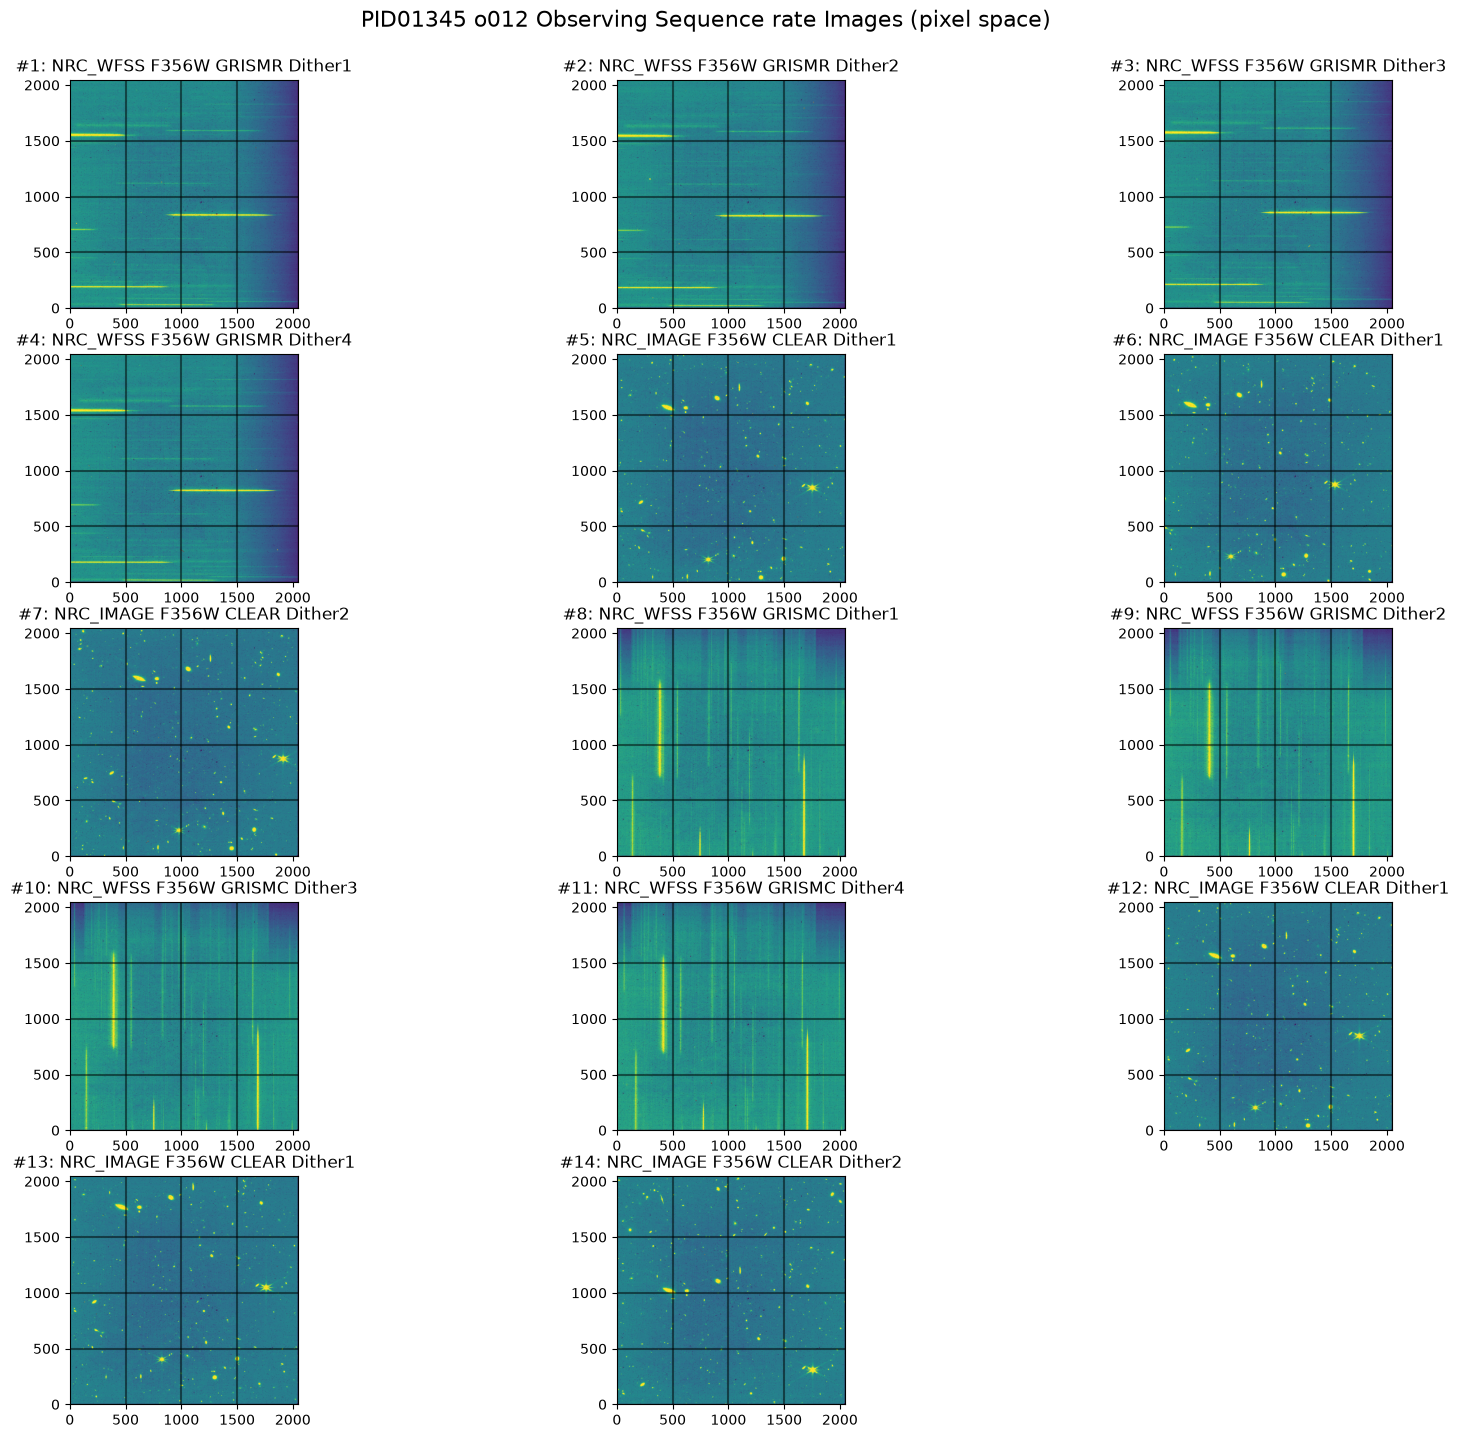

In [28]:
# Quick plot to visually illustrate the table above, showing the
# direct image and grism sequence for the downloaded data
if doviz:
    # Plot set up
    fig = plt.figure(figsize=(20, 35))
    cols = 3
    rows = int(np.ceil(len(rate_dfsort['PATHNAME']) / cols))
    
    # Loop over the rate files and plot them
    for plt_num, rf in enumerate(amod_rate_dfsort['PATHNAME']):
    
        # Determine where the subplot should be
        xpos = (plt_num % 40) % cols
        ypos = ((plt_num % 40) // cols) # // to make it an int.
    
        # Make the subplot
        ax = plt.subplot2grid((rows, cols), (ypos, xpos))
    
        # Open the data and plot it
        with fits.open(rf) as hdu:
            data = hdu[1].data
            data[np.isnan(data)] = 0  # Filling in nan data with 0s to help with the matplotlib color scale.
            
            display_vals = [np.nanpercentile(data, 1), np.nanpercentile(data, 99.5)]
            ax.imshow(data, vmin=display_vals[0], vmax=display_vals[1], origin='lower')
    
            # Add in grid lines as a visual aid
            for gridline in [500, 1000, 1500]:
                ax.axhline(gridline, color='black', alpha=0.5)
                ax.axvline(gridline, color='black', alpha=0.5)
            
            ax.set_title((f"#{plt_num+1}: {hdu[0].header['EXP_TYPE']} {hdu[0].header['FILTER']} "
                          f"{hdu[0].header['PUPIL']} Dither{hdu[0].header['PATT_NUM']}"))
            
    fig.suptitle(f'PID{program} o{sci_observtn} Observing Sequence rate Images (pixel space)', fontsize=16, x=0.5, y=0.9)

Additionally, you can look into what steps were performed and reference files used during the Detector1 stage of the pipeline. These calls can be used at any stage of the pipeline to see or confirm what different steps or reference files were used. We show both the direct image and the dispersed (grism) images below.

In [29]:
img_rate_files = rate_dfsort[rate_dfsort['EXP_TYPE'] == 'NRC_IMAGE']['PATHNAME']
print(f'Found {str(len(img_rate_files))} imaging rate files to process for level 2')

Found 12 imaging rate files to process for level 2


In [30]:
grism_rate_files = rate_dfsort[rate_dfsort['EXP_TYPE'] == 'NRC_WFSS']['PATHNAME']
print(f'Found {str(len(grism_rate_files))} grism rate files to process for level 2')

Found 16 grism rate files to process for level 2


In [31]:
# First, look at the direct images
dir_img_rate = img_rate_files.iloc[0]
check_steps_run(dir_img_rate)

# Next, look at the dispersed images
grism_img_rate = grism_rate_files.iloc[0]
check_steps_run(grism_img_rate)

jw01345012001_03101_00001_nrcblong_rate.fits - NRC_IMAGE
charge_migration: SKIPPED
clean_flicker_noise: SKIPPED
dark_sub: COMPLETE
dq_init: COMPLETE
gain_scale: SKIPPED
group_scale: SKIPPED
ipc: SKIPPED
jump: COMPLETE
linearity: COMPLETE
persistence: SKIPPED
picture_frame: SKIPPED
ramp_fit: COMPLETE
refpix: COMPLETE
saturation: COMPLETE
superbias: COMPLETE



jw01345012001_02101_00001_nrcalong_rate.fits - NRC_WFSS
charge_migration: SKIPPED
clean_flicker_noise: SKIPPED
dark_sub: COMPLETE
dq_init: COMPLETE
gain_scale: SKIPPED
group_scale: SKIPPED
ipc: SKIPPED
jump: COMPLETE
linearity: COMPLETE
persistence: SKIPPED
picture_frame: SKIPPED
ramp_fit: COMPLETE
refpix: COMPLETE
saturation: COMPLETE
superbias: COMPLETE



In [32]:
check_ref_file_used(dir_img_rate)  # direct image
check_ref_file_used(grism_img_rate)  # dispersed image

jw01345012001_03101_00001_nrcblong_rate.fits - NRC_IMAGE
crds: {'context_used': 'jwst_1584.pmap', 'sw_version': '14.0.2'}
dark: {'name': 'crds://jwst_nircam_dark_0403.fits'}
gain: {'name': 'crds://jwst_nircam_gain_0089.fits'}
linearity: {'name': 'crds://jwst_nircam_linearity_0049.fits'}
mask: {'name': 'crds://jwst_nircam_mask_0070.fits'}
readnoise: {'name': 'crds://jwst_nircam_readnoise_0223.fits'}
saturation: {'name': 'crds://jwst_nircam_saturation_0098.fits'}
sirskernel: {'name': 'crds://jwst_nircam_sirskernel_0002.asdf'}
superbias: {'name': 'crds://jwst_nircam_superbias_0243.fits'}



jw01345012001_02101_00001_nrcalong_rate.fits - NRC_WFSS
crds: {'context_used': 'jwst_1584.pmap', 'sw_version': '14.0.2'}
dark: {'name': 'crds://jwst_nircam_dark_0424.fits'}
gain: {'name': 'crds://jwst_nircam_gain_0097.fits'}
linearity: {'name': 'crds://jwst_nircam_linearity_0052.fits'}
mask: {'name': 'crds://jwst_nircam_mask_0076.fits'}
readnoise: {'name': 'crds://jwst_nircam_readnoise_0266.fits'}
saturation: {'name': 'crds://jwst_nircam_saturation_0097.fits'}
sirskernel: {'name': 'crds://jwst_nircam_sirskernel_0002.asdf'}
superbias: {'name': 'crds://jwst_nircam_superbias_0220.fits'}



In [33]:
# Print out the time benchmark
time_det1_end = time.perf_counter()
print(f"Runtime for Detector1: {(time_det1_end - time_det1_start)/60:0.0f} minutes")

Runtime for Detector1: 20 minutes


<hr style="border:1px solid gray"> </hr>

## 6. Image2 Pipeline
------------------

This section focuses on calibrating only the direct images in order to obtain a source catalog and segmentation mapping of the field to use as input into the Spec2 stage later. 

The [Image2 stage of the pipeline](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_image2.html), creates calibrated unrectified data products (`*_cal.fits` files). In this pipeline processing stage, the [world coordinate system (WCS)](https://jwst-pipeline.readthedocs.io/en/latest/jwst/assign_wcs/index.html#assign-wcs-step) is assigned, the data are [flat fielded](https://jwst-pipeline.readthedocs.io/en/latest/jwst/flatfield/index.html#flatfield-step), and a [photometric calibration](https://jwst-pipeline.readthedocs.io/en/latest/jwst/photom/index.html#photom-step) is applied to convert from units of countrate (ADU/s) to surface brightness (MJy/sr).

By default, the [background subtraction step](https://jwst-pipeline.readthedocs.io/en/latest/jwst/background_subtraction/index.html) is not performed on NIRCam imaging mode data. The background subtraction is turned off since there is no background template for the imaging mode and the local background is removed during the background correction for photometric measurements around individual sources. 

The input for the Image2 pipeline can be either the name of a `*_rate.fits` file, or an Image2 association file containing the `*_rate.fits` filename. Here we will loop over the imaging rate filenames pulled from the dataframe in the Detector1 stage, and call the Image2 pipeline on each. To use association files instead, simply replace the rate filename in the call with the association filename.

In [34]:
time_image2 = time.perf_counter()

The parameters in each of the [Image2 steps](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_image2.html) can be modified from the default values, including overwriting reference files that are used during this stage. This dictionary of the modified parameters for each of the steps is then fed into the `steps` parameter of the `Image2Pipeline` call. The syntax for modifying some of these parameters is below.

In [35]:
# Set up a dictionary to define how the Image2 pipeline should be configured.

# this sets up any entry to image2dict to be a dictionary itself
image2dict = defaultdict(dict)

# -----------------------------Set step parameters------------------------------
# Example overrides for whether or not certain steps should be skipped
# image2dict['resample']['skip'] = False

# ---------------------------Override reference files---------------------------
# Example overrides for various reference files
#   Files should be in the base local directory or provide full path
# image2dict['assign_wcs']['override_distortion'] = 'myfile.asdf'  # Spatial distortion (ASDF file)
# image2dict['assign_wcs']['override_filteroffset'] = 'myfile.asdf'  # Imager filter offsets (ASDF file)
# image2dict['assign_wcs']['override_specwcs'] = 'myfile.asdf'  # Spectral distortion (ASDF file)
# image2dict['assign_wcs']['override_wavelengthrange'] = 'myfile.asdf'  # Wavelength channel mapping (ASDF file)
# image2dict['flat_field']['override_flat'] = 'myfile.fits'  # Pixel flatfield
# image2dict['photom']['override_photom'] = 'myfile.fits'  # Photometric calibration array

In [36]:
# Run Image2 stage of pipeline, specifying:
# output directory to save *_cal.fits files
# save_results flag set to True so the rate files are saved

if doimage2:
    for rate in img_rate_files:
        img2 = Image2Pipeline.call(rate, output_dir=image2_dir, steps=image2dict, save_results=True)
else:
    print("Skipping Image2 processing.")

2026-09-29 19:50:07,844 - CRDS - INFO -  Syncing 1 files


2026-09-29 19:50:07,845 - CRDS - INFO -  Fetching  /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf    1.1 K bytes  (1 / 1 files) (0 / 1.1 K bytes)


2026-09-29 19:50:08,125 - stpipe.step - INFO - PARS-RESAMPLESTEP parameters found: /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf


2026-09-29 19:50:08,132 - CRDS - INFO -  Syncing 1 files


2026-09-29 19:50:08,133 - CRDS - INFO -  Fetching  /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-image2pipeline_0003.asdf    1.7 K bytes  (1 / 1 files) (0 / 1.7 K bytes)


...

2026-09-29 19:51:21,083 - jwst.pipeline.calwebb_image2 - INFO - ... ending calwebb_image2


2026-09-29 19:51:21,084 - jwst.stpipe.core - INFO - Results used CRDS context: jwst_1584.pmap


2026-09-29 19:51:21,176 - stpipe.step - INFO - Saved model in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_img/jw01345012003_02101_00001_nrcblong_cal.fits


2026-09-29 19:51:21,177 - stpipe.step - INFO - Step Image2Pipeline done


2026-09-29 19:51:21,177 - jwst.stpipe.core - INFO - Results used jwst version: 3.0.0


In [37]:
# Print out the time benchmark
time_image2_end = time.perf_counter()
print(f"Runtime for Image2: {(time_image2_end - time_image2):0.0f} seconds")

Runtime for Image2: 73 seconds


<hr style="border:1px solid gray"> </hr>

## 7. Image3 Pipeline
------------------

In this section we continue calibrating the direct images with the Image3 stage of the pipeline to obtain a source catalog and segmentation map of the field to use as input into the Spec2 stage later. In the [Image3 stage of the pipeline](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_image3.html), the individual `*_cal.fits` files for each of the dither positions are combined to one single distortion corrected image (`*_i2d.fits` files).

By default, the Image3 stage of the pipeline performs the following steps on NIRCam data:
* [tweakreg](https://jwst-pipeline.readthedocs.io/en/latest/jwst/tweakreg/README.html) - creates source catalogs of pointlike sources for each input image. The source catalog for each input image is compared to each other to derive coordinate transforms to align the images relative to each other.
* [skymatch](https://jwst-pipeline.readthedocs.io/en/latest/jwst/skymatch/description.html) - measures the background level from the sky to use as input into the subsequent outlier detection and resample steps.
* outlier detection - flags any remaining cosmic rays, bad pixels, or other artifacts not already flagged during the detector1 stage of the pipeline, using all input images to create a median image so that outliers in individual images can be identified.
* [resample](https://jwst-pipeline.readthedocs.io/en/latest/jwst/resample/main.html) - resamples each input image based on its WCS and distortion information and creates a single undistorted image.
* [source catalog](https://jwst-pipeline.readthedocs.io/en/latest/jwst/source_catalog/main.html) - creates a catalog of detected sources along with measured photometries and morphologies (i.e., point-like vs extended). Useful for quicklooks, but optimization is likely needed for specific science cases. Users may wish to experiment with changing the snr_threshold and deblend options. Modifications to the following parameters will not significantly improve data quality and it is advised to keep them at their default values: aperture_ee1, aperture_ee2, aperture_ee3, ci1_star_threshold, ci2_star_threshold.

In [38]:
time_image3 = time.perf_counter()

Find and sort all of the input image2 cal files, ensuring use of absolute paths

In [39]:
# Science Files need the cal.fits files
sstring = os.path.join(image2_dir, 'jw*cal.fits')
img3_cal_files = sorted(glob.glob(sstring))
for ii, cal_relpath in enumerate(img3_cal_files):
    img3_cal_files[ii] = os.path.abspath(cal_relpath)
img3_cal_files = np.array(img3_cal_files)

print(f'Found {str(len(img3_cal_files))} imaging cal files to process for level 3')

Found 12 imaging cal files to process for level 3


### Create Image3 Association Files

An association file lists the exposures to calibrated together in the Image3 stage of the pipeline. Note that an association file is available for download from MAST, with a filename of `*image3_asn.json`. Additionally, you can download the `_pool.csv` file for a specific observation and create associations directly from the pool file using the [asn_generate](https://jwst-pipeline.readthedocs.io/en/latest/jwst/associations/asn_generate.html) function with the latest version of the pipeline. In both of these cases, the pipeline is expecting the files being calibrated to exist in the same directory that the association is in. Below, we show how to create an image3 association file by providing a [list of exposures](https://jwst-pipeline.readthedocs.io/en/latest/jwst/associations/asn_from_list.html) that we have processed through the pipeline and saved in separate directories. Also note that the output products will have a rootname that is specified by the `product_name` in the association file. For this tutorial, the rootname of the output products will end with `image3_asn.json`.

In [40]:
# Create a Level 3 Association for each blocking filter
if doimage3:

    # Parameters to be used for the Image3 association creation
    img3_pid = str(program) # Associations are only set up to combine for the same program & observation
    img3_obs = str(sci_observtn) # Associations are only set up to combine for the same program & observation
    img3_pupil = 'CLEAR' # For imaging mode, the pupil wheel is set to clear
    img3_ins = 'NIRCAM'

    # Identify the unique filters used for the direct images
    img3_all_filters = np.array([fits.getval(cf, 'FILTER') for cf in img3_cal_files])
    img3_uniq_filters = np.unique(img3_all_filters)
    
    # Loop over unique filter values
    for img3_filter in img3_uniq_filters:
        img3_indx = np.where(img3_all_filters == img3_filter)[0]
        img3_filter_files = img3_cal_files[img3_indx]

        # Set up the association filename to match the default pipeline level3 naming output
        img3_product_name = f"jw{img3_pid}-o{img3_obs}_{img3_ins}_{img3_filter}-{img3_pupil}".lower()
        img3_asn_filename = img3_product_name + '_image3_asn.json'
    
        img3_association = asn_from_list.asn_from_list(img3_filter_files, rule=DMS_Level3_Base,
                                                       product_name=img3_product_name)
    
        img3_association.data['asn_type'] = 'image3'
        img3_association.data['program'] = img3_pid
    
        # Format association as .json file
        _, serialized = img3_association.dump(format="json")

        # Write out association file
        img3_asn_pathname = os.path.join(sci_dir, img3_asn_filename)
        with open(img3_asn_pathname, "w") as fd:
            fd.write(serialized)
        print(f'Writing image3 association: {img3_asn_pathname}')

Writing image3 association: /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/jw01345-o012_nircam_f356w-clear_image3_asn.json


/home/runner/micromamba/envs/ci-env/lib/python3.13/site-packages/jwst/associations/association.py:232: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)


Take a quick look at the contents of the image3 association file to see which files will be combined

In [41]:
if doimage3:
    image3_asns = glob.glob(os.path.join(sci_dir, "*image3*_asn.json"))
    
    # open the image3 association to look at
    image3_asn_data = json.load(open(image3_asns[0]))
    print(f'asn_type : {image3_asn_data["asn_type"]}')
    print(f'code_version : {image3_asn_data["code_version"]}')
    
    # in particular, take a closer look at the product filenames with the association file:
    for product in image3_asn_data['products']:
        for key, value in product.items():
            if key == 'members':
                print(f"{key}:")
                for member in value:
                    print(f"    {member['expname']} {member['exptype']}")
            else:
                print(f"{key}: {value}")

asn_type : image3
code_version : 3.0.0
name: jw01345-o012_nircam_f356w-clear
members:
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_img/jw01345012001_03101_00001_nrcalong_cal.fits science
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_img/jw01345012001_03101_00001_nrcblong_cal.fits science
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_img/jw01345012001_05101_00001_nrcalong_cal.fits science
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_img/jw01345012001_05101_00001_nrcblong_cal.fits science
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_img/jw01345012001_05

### Run Image3

In Image3, the `*_cal.fits` individual pointing files will be calibrated into a single combined `*_i2d.fits` image. The parameters in each of the [Image3 steps](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_image3.html) can be modified from the default values, including overwriting reference files that are used during this stage. This dictionary of the modified parameters for each of the steps is then fed into the `steps` parameter of the `Image3Pipeline` call. The syntax for modifying some of these parameters is below; the full list of parameters can be found in the [tweakreg](https://jwst-pipeline.readthedocs.io/en/latest/jwst/tweakreg/index.html), [skymatch](https://jwst-pipeline.readthedocs.io/en/stable/jwst/skymatch/index.html), [outlier detection](https://jwst-pipeline.readthedocs.io/en/latest/jwst/outlier_detection/index.html), [resample](https://jwst-pipeline.readthedocs.io/en/latest/jwst/resample/index.html) and [sourcecatalog](https://jwst-pipeline.readthedocs.io/en/latest/jwst/source_catalog/index.html) documentation.


In [42]:
# Set up a dictionary to define how the Image3 pipeline should be configured

# this sets up any entry to image3dict to be a dictionary itself
image3dict = defaultdict(dict)

# -----------------------------Set step parameters------------------------------
# Example overrides for whether or not certain steps should be skipped
#   Some of these example values differ from default values to improve the demo scene
# image3dict['outlier_detection']['skip'] = True

# Example parameters for the source_catalog step
# image3dict['source_catalog']['kernel_fwhm'] = 5.0
# image3dict['source_catalog']['snr_threshold'] = 10.0
# image3dict['source_catalog']['npixels'] = 50
# image3dict['source_catalog']['deblend'] = True

# Example parameters for the tweakreg step
# image3dict['tweakreg']['snr_threshold'] = 20
# image3dict['tweakreg']['abs_refcat'] = 'GAIADR3'
# image3dict['tweakreg']['searchrad'] = 3.0,
# image3dict['tweakreg']['kernel_fwhm'] = 2.302
# image3dict['tweakreg']['fitgeometry'] = 'shift'

# ---------------------------Override reference files---------------------------
# Example overrides for various reference files
#   Files should be in the base local directory or provide full path
# image3dict['source_catalog']['override_apcorr'] = 'myfile.fits'  # Aperture correction parameters
# image3dict['source_catalog']['override_abvegaoffset'] = 'myfile.asdf'  # Data to convert from AB to Vega magnitudes (ASDF file)

In [43]:
# Run Image3
if doimage3:
    asn_files = np.sort(glob.glob(os.path.join(sci_dir, '*image3_asn.json')))
    for asn in asn_files:
        img3 = Image3Pipeline.call(asn, output_dir=image3_dir, steps=image3dict, save_results=True)
else:
    print('Skipping Image3 processing')

2026-09-29 19:51:21,321 - CRDS - INFO -  Syncing 1 files


2026-09-29 19:51:21,327 - CRDS - INFO -  Fetching  /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0043.asdf    1.6 K bytes  (1 / 1 files) (0 / 1.6 K bytes)


2026-09-29 19:51:21,617 - stpipe.step - INFO - PARS-TWEAKREGSTEP parameters found: /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-tweakregstep_0043.asdf


2026-09-29 19:51:21,624 - stpipe.step - INFO - PARS-RESAMPLESTEP parameters found: /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf


2026-09-29 19:51:21,631 - CRDS - INFO -  Syncing 1 files


...

2026-09-29 19:53:16,635 - stpipe.step - INFO - Saved model in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_img/jw01345-o012_nircam_f356w-clear_segm.fits


2026-09-29 19:53:16,636 - jwst.source_catalog.source_catalog_step - INFO - Wrote segmentation map: jw01345-o012_nircam_f356w-clear_segm.fits


2026-09-29 19:53:16,638 - stpipe.step - INFO - Step source_catalog done


2026-09-29 19:53:16,643 - stpipe.step - INFO - Step Image3Pipeline done


2026-09-29 19:53:16,643 - jwst.stpipe.core - INFO - Results used jwst version: 3.0.0


In [44]:
# Print out the time benchmark
time_image3_end = time.perf_counter()
print(f"Runtime for Image3: {(time_image3_end - time_image3)/60:0.0f} minutes")

Runtime for Image3: 2 minutes


<hr style="border:1px solid gray"> </hr>

## 8. Visualize Image3 Output Products
------------------

Using the combined image (`*_i2d.fits` ), the segmentation map files (`*_segm.fits`), and the source catalog  (`*cat.ecsv`) produced by the Image3 stage of the pipeline, we can visually inspect the final direct image and the quality of the detected sources. Accurate source locations in the catalog are vital to achieving high quality spectral extraction in the Spec2 stage of the pipeline.

In [45]:
# Find the outputs of the Image3 pipeline, which will be needed for processing the spectral data
# Print which outputs were found for reference

# Combined (mosaic) image
image3_i2d = np.sort(glob.glob(os.path.join(image3_dir, '*i2d.fits')))
print('Direct images:')
for i2d_filename in image3_i2d:
    print(f"  {os.path.basename(i2d_filename)}")

# Segmentation map that defines the extent of sources
image3_segm = np.sort(glob.glob(os.path.join(image3_dir, '*segm.fits')))
print('Segmentation maps:')
for seg_filename in image3_segm:
    print(f"  {os.path.basename(seg_filename)}")
    
# Source catalog that defines the RA/Dec of sources
image3_cat = np.sort(glob.glob(os.path.join(image3_dir, '*cat.ecsv')))
print('Source catalogs:')
for cat_filename in image3_cat:
    print(f"  {os.path.basename(cat_filename)}")

Direct images:
  jw01345-o012_nircam_f356w-clear_i2d.fits
Segmentation maps:
  jw01345-o012_nircam_f356w-clear_segm.fits
Source catalogs:
  jw01345-o012_nircam_f356w-clear_cat.ecsv


### i2d & segementation mapping

The segmentation maps are used to help construct the source catalog. Let's take a look at those to ensure we agree with what is being defined as a source. In the following figures, the combined image is shown on the left and the the segmentation map is shown on the right, where each black blob in the segmentation map should correspond to a physical target. The sources identified in the source catalog are overlayed on top of both of these, where what has been defined as an extended source by the pipeline is shown as a blue circle, and what has been defined as a point source by the pipeline is shown as a pink square. This definition affects the extraction box in the WFSS images as well as in the contamination correction step of the pipeline, so it is important to get correct.

It's important to check the source catalog details for your sources of interest. In some cases where multiple sources are close together on the sky, it is possible for the sources to be blended into a single catalog object. More often, the pipeline can incorrectly categorize an object as a point or extended source. If using the demo data, you can see in the figure below that many of the source in the pink squares, indicating that the pipeine determined them to be point sources, are in fact extended. If your targets of interest suffer from blending or incorrect categorization in the source catalog, then the source catalog step should be re-run with modified parameters.

In the case of extended sources that are incorrectly identified as point sources, the subsequent spectral extraction may be poor because the extraction box will not be large enough to contain the entire source. Tweaks to the [source_catalog parameters](https://jwst-pipeline.readthedocs.io/en/stable/jwst/source_catalog/arguments.html) may help correct these problems.

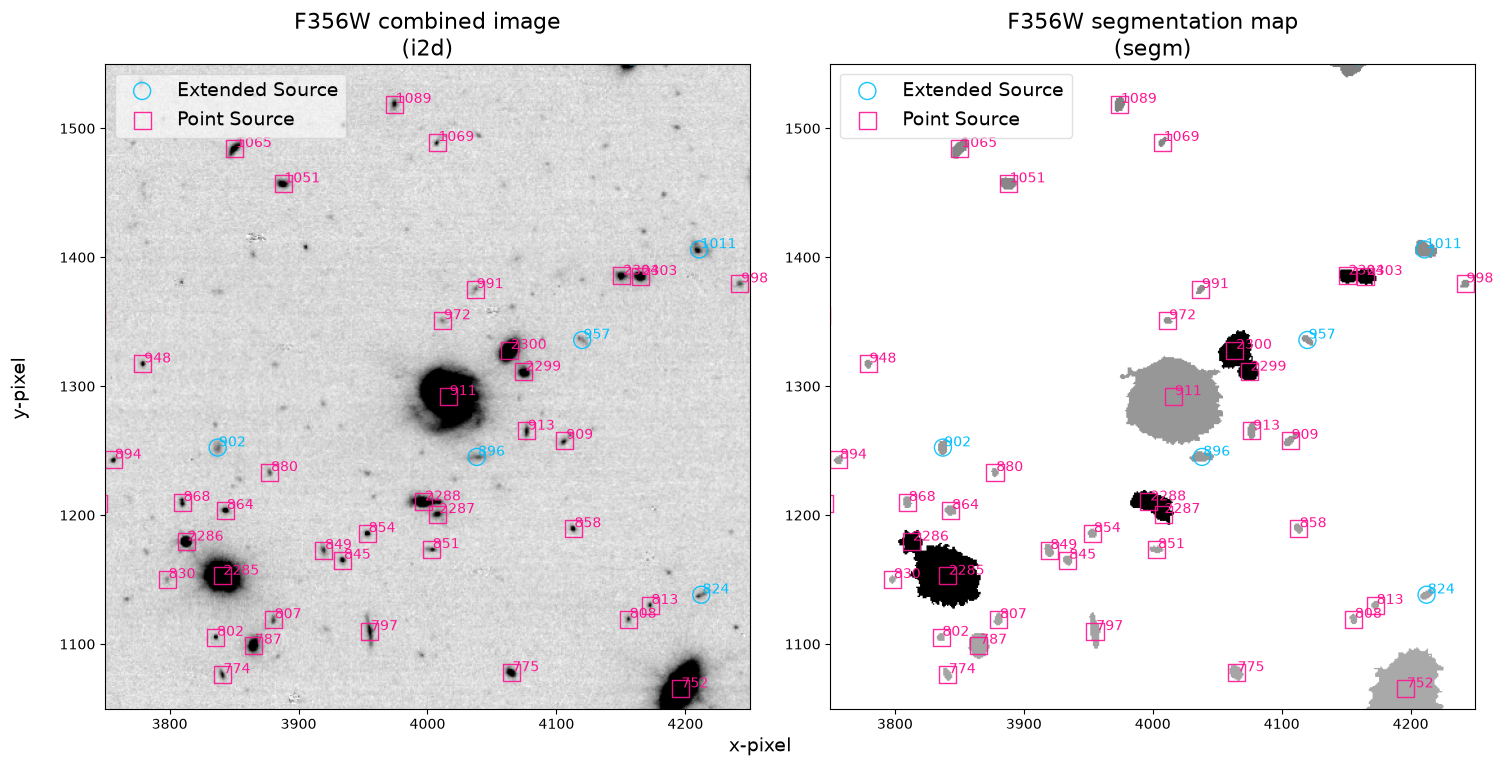

In [46]:
if doviz:            
    cols = 2
    rows = len(image3_i2d)
    
    fig = plt.figure(figsize=(15, 15*(rows/2)))
    
    for plt_num, img in enumerate(np.sort(np.concatenate([image3_segm, image3_i2d]))):
    
        # Determine where the subplot should be
        xpos = (plt_num % 40) % cols
        ypos = ((plt_num % 40) // cols)
    
        # Make the subplot
        ax = plt.subplot2grid((rows, cols), (ypos, xpos))
    
        if 'i2d' in img:
            cat = Table.read(img.replace('i2d.fits', 'cat.ecsv'))
            cmap = 'gist_gray_r'
        else:
            cmap = 'gist_gray_r'
            
        # Plot the image
        with fits.open(img) as hdu:
            display_vals = [np.nanpercentile(hdu[1].data, 1), np.nanpercentile(hdu[1].data, 99)]
            ax.imshow(hdu[1].data, vmin=display_vals[0], vmax=display_vals[1], origin='lower', cmap=cmap)
            title = f"{hdu[0].header['FILTER']}"
    
        # Also plot the associated catalog
        extended_sources = cat[cat['is_extended'] == 1] # 1 is True; i.e. is extended
        point_sources = cat[cat['is_extended'] == 0] # 0 is False; i.e. is a point source

        for color, sources, source_type, marker in zip(['deepskyblue', 'deeppink'],
                                                       [extended_sources, point_sources],
                                                       ['Extended Source', 'Point Source'], 
                                                       ['o', 's']):
            # Plot the sources
            ax.scatter(sources['xcentroid'], sources['ycentroid'], marker=marker, s=150,
                       facecolors='None', edgecolors=color, alpha=0.9)
    
            # Add source labels 
            for i, source_num in enumerate(sources['label']):
                ax.annotate(source_num, 
                            (sources['xcentroid'][i]+1, sources['ycentroid'][i]+1), 
                            fontsize=10,
                            color=color)
            ax.scatter(-999, -999, marker=marker, label=source_type, s=150, facecolors='None', edgecolors=color, alpha=0.9)

        # Set titles
        if 'i2d' in img:
            ax.set_title(f"{title} combined image\n(i2d)", fontsize=16)
        else:
            ax.set_title(f"{title} segmentation map\n(segm)", fontsize=16)
        
        # Zoom in on a smaller region 
        # (default to a region centered on one of the 5 sources to be examined later).
        ax.set_xlim(3750, 4250)
        ax.set_ylim(1050, 1550)

        ax.legend(framealpha=0.6, fontsize=14, loc='upper left')

    # More labels 
    fig.supxlabel('x-pixel', fontsize=14)
    fig.supylabel('y-pixel', fontsize=14, x=0)
    
    # Helps to make the axes not overlap ; you can also set this manually if this doesn't work
    plt.tight_layout()

In addition to the segmentation mapping, the source catalog itself can be useful to look at to examine the source centroids, calculated fluxes, and source extents

In [47]:
# Print a source catalogs to illustrate the contents
cat = Table.read(image3_cat[0])
cat

label,xcentroid,ycentroid,sky_centroid,aper_bkg_flux,aper_bkg_flux_err,aper30_flux,aper30_flux_err,aper50_flux,aper50_flux_err,aper70_flux,aper70_flux_err,aper_total_flux,aper_total_flux_err,aper30_abmag,aper30_abmag_err,aper50_abmag,aper50_abmag_err,aper70_abmag,aper70_abmag_err,aper_total_abmag,aper_total_abmag_err,aper30_vegamag,aper30_vegamag_err,aper50_vegamag,aper50_vegamag_err,aper70_vegamag,aper70_vegamag_err,aper_total_vegamag,aper_total_vegamag_err,CI_50_30,CI_70_50,CI_70_30,is_extended,sharpness,roundness,nn_label,nn_dist,isophotal_flux,isophotal_flux_err,isophotal_abmag,isophotal_abmag_err,isophotal_vegamag,isophotal_vegamag_err,isophotal_area,semimajor_sigma,semiminor_sigma,ellipticity,orientation,sky_orientation,sky_bbox_ll,sky_bbox_ul,sky_bbox_lr,sky_bbox_ur
,,,"deg,deg",Jy,Jy,Jy,Jy,Jy,Jy,Jy,Jy,Jy,Jy,,,,,,,,,,,,,,,,,,,,,,,,pix,Jy,Jy,,,,,pix2,pix,pix,,deg,deg,"deg,deg","deg,deg","deg,deg","deg,deg"
int32,float64,float64,SkyCoord,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,float64,float32,int32,float64,float64,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,SkyCoord,SkyCoord,SkyCoord,SkyCoord
1,2127.0363,7.0516,"214.9782925290972,52.8863099752374",9.468629e-09,5.513374e-11,7.986461e-09,2.016558e-09,1.744858e-08,2.937605e-09,4.129365e-08,4.851863e-09,5.923713e-08,6.960160e-09,29.144114,0.244442,28.295600,0.168940,27.360292,0.120616,26.968515,0.120616,26.332466,0.244442,25.483952,0.168940,24.548644,0.120616,24.156867,0.120616,2.1848,2.3666,5.1705,True,1.185397,nan,9,86.586775,9.100369e-08,7.152106e-09,26.502352,0.082142,23.690705,0.082142,53.0,2.484357,1.533873,0.382587,335.060367,15.767966,"214.97847509892404,52.88634277352766","214.97827761271373,52.88644541356453","214.9782671951929,52.88619713024728","214.97806970915346,52.886299769939214"
2,1133.4770,7.9517,"214.99705707505805,52.899473795849765",9.330979e-09,5.008369e-11,7.716837e-09,2.421139e-09,nan,nan,nan,nan,nan,nan,29.181402,0.296280,nan,nan,nan,nan,nan,nan,26.369754,0.296280,nan,nan,nan,nan,nan,nan,nan,nan,nan,False,nan,nan,7,33.988416,4.552995e-08,5.888066e-09,27.254257,0.132045,24.442609,0.132045,26.0,2.211065,0.960031,0.565806,4.688027,45.395626,"214.99718305686565,52.899523116416624","214.99707333369346,52.89958015594004","214.99699393881787,52.899390743175026","214.99688421573163,52.899447782524206"
3,970.2737,16.0662,"214.99996562525004,52.901726703958076",9.838613e-09,5.575136e-11,4.631041e-08,2.615185e-09,9.099201e-08,3.766673e-09,1.919380e-07,6.054858e-09,2.753415e-07,8.685897e-09,27.235803,0.059644,26.502492,0.044039,25.692098,0.033721,25.300321,0.033721,24.424156,0.059644,23.690844,0.044039,22.880450,0.033721,22.488673,0.033721,1.9648,2.1094,4.1446,False,0.472186,-1.277075,36,62.407663,5.653323e-07,1.371529e-08,24.519241,0.026026,21.707593,0.026026,163.0,4.133222,2.107636,0.490074,298.064293,338.771892,"215.0003006402757,52.90173187678888","214.99986173991502,52.90196004576616","214.99996019414212,52.901493613660726","214.99952129440007,52.90172178138335"
4,1641.4718,11.8837,"214.98736518524402,52.892793761882835",9.431592e-09,4.509418e-11,4.271515e-09,2.567154e-09,9.076020e-09,3.736997e-09,2.959911e-08,6.104016e-09,4.246092e-08,8.756416e-09,29.823545,0.510974,29.005261,0.374390,27.721803,0.203569,27.330027,0.203569,27.011897,0.510974,26.193614,0.374390,24.910155,0.203569,24.518379,0.203569,2.1248,3.2612,6.9294,True,0.486410,-0.341648,8,29.207459,1.166777e-07,9.664208e-09,26.232530,0.086399,23.420883,0.086399,70.0,3.446440,1.856292,0.461388,339.006355,19.713954,"214.98757428302326,52.892822820498964","214.98733290113435,52.89294828783802","214.98730960006714,52.89263747649529","214.98706821844348,52.89276294329772"
5,1349.6100,29.7138,"214.9924923265234,52.89686094361995",1.047450e-08,7.551143e-11,8.403071e-07,8.16

In all likelihood, you will need to rerun Image3 with customized parameter values in order to return an optimal source catalog to use with your NIRCam WFSS data. You can additionally modify the source catalog so that Spec2 and Spec3 only run on the sources that you care most about. 

<hr style="border:1px solid gray"> </hr>

## 9. Spec2 Pipeline
------------------
After running Image3 and thus creating the the segmentation map and source catalog, the [Spec2 pipeline](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_spec2.html#calwebb-spec2) is ready to be run. The spec2 pipeline first runs [assign_wcs](https://jwst-pipeline.readthedocs.io/en/latest/jwst/assign_wcs/main.html), [background](https://jwst-pipeline.readthedocs.io/en/latest/jwst/background_subtraction/description.html), and [flat_field](https://jwst-pipeline.readthedocs.io/en/latest/jwst/flatfield/main.html) corrections first on the full-frame `*_rate.fits` files. The [srctype](https://jwst-pipeline.readthedocs.io/en/latest/jwst/srctype/description.html) step is run to determine the extent of the extraction box size before the [extract_2d](https://jwst-pipeline.readthedocs.io/en/latest/jwst/extract_2d/main.html) step is run, producing individual cutouts for the brightest 100 (by default) sources defined in the Image3 source catalog. The number of sources to extract is a user-settable parameter. The [wfss_contam](https://jwst-pipeline.readthedocs.io/en/latest/jwst/wfss_contam/description.html) step is run towards the end of the [extract_2d](https://jwst-pipeline.readthedocs.io/en/latest/jwst/extract_2d/main.html) step and is currently not on by default as the step is being improved. The [photom](https://jwst-pipeline.readthedocs.io/en/latest/jwst/photom/main.html) step is then run on the cutouts, producing flux calibrated 2-D spectral (`*_cal.fits`) files. The [extract_1d](https://jwst-pipeline.readthedocs.io/en/latest/jwst/extract_1d/description.html) step is run last, producing level 2 `*_x1d.fits` files.

In [48]:
time_spec2 = time.perf_counter()

### Create Spec2 Association File

As with the imaging part of the pipeline, there are association files for spec2. These are a bit more complex in that they need to have the dispersed data, direct image, source catalog, and segmentation map included as members. For the dispersed data, the rate files are used as inputs, similar to Image2. Also like Image2, there should be one association file for each dispersed image dither position in an observing sequence.

Like Image3, we create a spec2 association file manually by providing a [list of exposures](https://jwst-pipeline.readthedocs.io/en/latest/jwst/associations/asn_from_list.html) that we have processed through the pipeline and saved in separate directories rather than downloading directly from MAST or using the [pool files](https://jwst-pipeline.readthedocs.io/en/latest/jwst/associations/asn_generate.html). Note that the output products will have a rootname that is specified by the `product_name` in the association file. For this tutorial, the association filenames will end with `_spec2_asn.json`.

In [49]:
def write_spec2asn(grismfile, dimagefiles, catalogfiles, segmfiles, prodname):
    
    # Define the basic association of science files
    # # Wrap grismfile in a list since input is single exposure
    asn = asn_from_list.asn_from_list([grismfile], rule=DMSLevel2bBase, product_name=prodname)

    # Which blocking filter does the dispersed image use?
    grism_filter = fits.getval(grismfile, 'FILTER')
    grism_pid = fits.getval(grismfile, 'PROGRAM')
    grism_obs = fits.getval(grismfile, 'OBSERVTN')

    # Find the direct images with the same matching program, observation, and filter to use
    dir_img_match = []
    for dir_img in dimagefiles:
        img_pid = fits.getval(dir_img, 'PROGRAM')
        img_obs = fits.getval(dir_img, 'OBSERVTN')
        img_filter = fits.getval(dir_img, 'FILTER')

        if img_filter == grism_filter and img_pid == grism_pid and img_obs == grism_obs:
            dir_img_match.append(dir_img)

    # Ensure that there is only one match found for the grism image
    if len(dir_img_match) == 0:
        raise ValueError((f'Could not find a matching i2d image for {grismfile}. Please ensure that you '
                          f'have processed the appropriate data for {grism_pupil} PID {grism_pid} o{grism_obs}'))
    elif len(dir_img_match) > 1:
        raise ValueError((f'Multiple i2ds found matching: {grism_pupil} PID {grism_pid} o{grism_obs}. Please '
                          f'download the associations directly from MAST to proceed further.'))
    else:
        # There should only be one match per filter/program/observation combination, so grab that one
        dir_img_match = dir_img_match[0]
        
    # There should be a set of i2d, segm, and cat that have the same rootname, so we will just replace the filetype suffix
    dir_seg_match = dir_img_match.replace('_i2d.fits', '_segm.fits')
    dir_cat_match = dir_img_match.replace('_i2d.fits', '_cat.ecsv')
    
    # Add the direct image, catalog, and segmentation files
    asn['products'][0]['members'].append({'expname': dir_img_match, 'exptype': 'direct_image'})
    asn['products'][0]['members'].append({'expname': dir_cat_match, 'exptype': 'sourcecat'})
    asn['products'][0]['members'].append({'expname': dir_seg_match, 'exptype': 'segmap'})
    
    spec2_asnfile = os.path.join(sci_dir, os.path.basename(grismfile).replace('rate.fits', 'spec2_asn.json'))

    # Write the association to a json file
    _, serialized = asn.dump()
    with open(spec2_asnfile, 'w') as outfile:
        outfile.write(serialized)

    print(f'Writing spec2 association: {spec2_asnfile}')
    return spec2_asnfile

In [50]:
# Find the rate files using our dataframe table that we created in the detector1 stage of the notebook
grism_rate_files = rate_dfsort[rate_dfsort['EXP_TYPE'] == 'NRC_WFSS']['PATHNAME']
print(f'Found {str(len(grism_rate_files))} grism rate files to process for level 2')

# Use the rate files and image3 output products to define spec2 association files
# Strip off the path information from the image3 output products, since the pipeline 
# ignores the given path and always looks for those files in the current working directory.
# We'll work around this by changing the working directory before calling the pipeline.
if dospec2:
    for file in grism_rate_files:
        asnfile = write_spec2asn(file, image3_i2d, image3_cat, image3_segm, 'Level2')

Found 16 grism rate files to process for level 2
Writing spec2 association: /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/jw01345012001_02101_00001_nrcalong_spec2_asn.json
Writing spec2 association: /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/jw01345012001_02101_00001_nrcblong_spec2_asn.json
Writing spec2 association: /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/jw01345012001_02101_00002_nrcblong_spec2_asn.json
Writing spec2 association: /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/jw01345012001_02101_00002_nrcalong_spec2_asn.json
Writing spec2 association: /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/j

/home/runner/micromamba/envs/ci-env/lib/python3.13/site-packages/jwst/associations/association.py:232: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)


In [51]:
# Take a quick look at the contents of an example spec2 association file to
# get a feel for what is being associated
if dospec2:
    spec2_asns = glob.glob(os.path.join(sci_dir, "*spec2*_asn.json"))
    
    # Look at one of the association files
    asn_data = json.load(open(spec2_asns[0]))
    print(f'asn_type : {asn_data["asn_type"]}')
    print(f'code_version : {asn_data["code_version"]}')
    
    # In particular, take a closer look at the product filenames with the association file:
    for product in asn_data['products']:
        for key, value in product.items():
            if key == 'members':
                print(f"{key}:")
                for member in value:
                    print(f"    {member['expname']} : {member['exptype']}")
            else:
                print(f"{key}: {value}")

asn_type : None
code_version : 3.0.0
name: /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage1/jw01345012001_02101_00004_nrcblong
members:
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage1/jw01345012001_02101_00004_nrcblong_rate.fits : science
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_img/jw01345-o012_nircam_f356w-clear_i2d.fits : direct_image
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_img/jw01345-o012_nircam_f356w-clear_cat.ecsv : sourcecat
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_img/jw01345-o012_nircam_f356w-clear_segm.fits : segmap


### Run Spec2

In Spec2, the `*_rate.fits` files run through various corrections before using the source catalog to extract the 100 (by default) brightest sources into 1-D spectra (level 2 `*_x1d.fits` files). The parameters in each of the [Spec2 steps](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_spec2.html) can be modified from the default values, including overwriting reference files that are used during this stage and saving additional files. This dictionary of the modified parameters for each of the steps is then fed into the `steps` parameter of the `Spec2Pipeline` call. The syntax for modifying some of these parameters is below. In particular, we show the option of only extracting the 10 brightest sources by setting `wfss_nbright`, as well as showing several options related to the contamination step, including turning on the step, saving the simulated images, and using additional cores to process more quickly. 

The contamination correction step is turned off by default in pipeline version 3.0.0 while development work to make the results more robust is ongoing. If you run this step, check the results carefully. We also show how to save the background subtracted full-frame file as an intermediate product (*_bsub.fits). These background products are expected to be a default output in an upcoming pipeline build.

In [52]:
# Set up a dictionary to define how the Spec2 pipeline should be configured.

# this sets up any entry to spec2dict to be a dictionary itself
spec2dict = defaultdict(dict)

# ---------------------------Override reference files---------------------------
# Overrides for various reference files (example).
#   Files should be in the base local directory or provide full path.
# spec2dict['assign_wcs']['override_distortion'] = 'myfile.asdf'  # Spatial distortion (ASDF file)
# spec2dict['assign_wcs']['override_filteroffset'] = 'myfile.asdf'  # Imager filter offsets (ASDF file)
# spec2dict['assign_wcs']['override_specwcs'] = 'myfile.asdf'  # Spectral distortion (ASDF file)
# spec2dict['assign_wcs']['override_wavelengthrange'] = 'myfile.asdf'  # Wavelength channel mapping (ASDF file)
# spec2dict['bkg_subtract']['override_bkg'] = 'myfile.fits' # WFSS Background subtraction
# spec2dict['extract_2d']['override_wavelengthrange'] = 'myfile.asdf'  # Wavelength channel mapping (ASDF file)
# spec2dict['flat_field']['override_flat'] = 'myfile.fits'  # Pixel flatfield
# spec2dict['wfss_contam']['override_wavelengthrange'] = 'myfile.asdf'  # Wavelength channel mapping (ASDF file)
# spec2dict['wfss_contam']['override_photom'] = 'myfile.fits'  # Photometric calibration array
# spec2dict['photom']['override_photom'] = 'myfile.fits'  # Photometric calibration array

# -----------------------------Set step parameters------------------------------
# Overrides for whether or not certain steps should be skipped (example).
spec2dict['bkg_subtract']['skip'] = False  # perform the background subtraction
spec2dict['bkg_subtract']['save_results'] = True  # save background subtracted full-frame images
spec2dict['bkg_subtract']['wfss_mmag_extract'] = 24.0  # Ignore sources fainter than this when masking for background creation
# spec2dict['bkg_subtract']['wfss_mask'] = 'my_mask.fits'  # Provide your own background file for background subtraction
# spec2dict['flat_field']['save_results'] = True  # save the background subtracted, flat-field corrected, full-frame images
spec2dict['extract_2d']['wfss_nbright'] = 10  # only extract the 10 brightest sources
# spec2dict['wfss_contam']['skip'] = False  # uncomment to turn on contamination correction
# spec2dict['wfss_contam']['save_simulated_image'] = True  # save the simulated images produced by the pipeline
# spec2dict['wfss_contam']['maximum_cores'] = '1'  # (quarter, half, all, or the default='1'); This will speed up the calibration time

In [53]:
if dospec2:
    for spec2_asn in spec2_asns:
        os.chdir(image3_dir) # This is necessary since the pipeline looks in the current directory for the catalog
        spec2 = Spec2Pipeline.call(spec2_asn, steps=spec2dict, save_results=True, output_dir=spec2_dir)
        os.chdir(cwd) # Change back into your original directory
else:
    print('Skipping Spec2 processing for SCI data')

2026-09-29 19:53:19,528 - CRDS - INFO -  Syncing 1 files


2026-09-29 19:53:19,529 - CRDS - INFO -  Fetching  /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-backgroundstep_0001.asdf    1.2 K bytes  (1 / 1 files) (0 / 1.2 K bytes)


2026-09-29 19:53:19,789 - stpipe.step - INFO - PARS-BACKGROUNDSTEP parameters found: /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-backgroundstep_0001.asdf


2026-09-29 19:53:19,799 - CRDS - ERROR -  Error determining best reference for 'pars-targcentroidstep'  =   Unknown reference type 'pars-targcentroidstep'


2026-09-29 19:53:19,805 - CRDS - INFO -  Syncing 1 files


...

2026-09-29 20:00:40,381 - jwst.pipeline.calwebb_spec2 - INFO - Ending calwebb_spec2


2026-09-29 20:00:40,381 - jwst.stpipe.core - INFO - Results used CRDS context: jwst_1584.pmap


2026-09-29 20:00:40,762 - stpipe.step - INFO - Saved model in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_spec/jw01345012001_07101_00004_nrcalong_cal.fits


2026-09-29 20:00:40,763 - stpipe.step - INFO - Step Spec2Pipeline done


2026-09-29 20:00:40,763 - jwst.stpipe.core - INFO - Results used jwst version: 3.0.0


In [54]:
# Print out the time benchmark
time_spec2_end = time.perf_counter()
print(f"Runtime for Spec2: {(time_spec2_end - time_spec2)/60:0.0f} minutes")

Runtime for Spec2: 7 minutes


## 10. Understanding Spec2 Output Products

#### Background-subtracted files (*_bsub.fits)

For WFSS data, the background subtraction step masks pixels containing signal from discrete sources and uses the remaining pixels, which are assumed to contain only background signal, to determine the background level. As described in the [Background step documentation](https://jwst-pipeline.readthedocs.io/en/stable/jwst/background_subtraction/description.html#wfss-mode), the mean value across these background pixels is used to scale a pre-existing background image. The scaled background is then subtracted from the data.

Since we set `spec2dict['bkg_subtract']['save_results'] = True` above, the results of the step are saved in a file with the suffix "bsub.fits". This file contains the background-subtracted data, as well as the mask used during the mean background calculation. 

In [55]:
bsub_file = os.path.join(spec2_dir, os.path.basename(grism_rate_files[0]).replace('rate.fits', 'bsub.fits'))

In [56]:
bsub_model = datamodels.open(bsub_file)

In [57]:
rate_file = os.path.join(det1_dir, os.path.basename(grism_rate_files[0]))
rate_model = datamodels.open(rate_file)

Let's look at the data before and after background subtraction. Note that the two images have different scaling. The image of the data after background subtraction is shown with a significantly lower maximum value, in order to highlight the appearance of any residual background signal.

In addition, show the mask used within the background step. Yellow pixels in this image are the pixels used to determine the mean background level. Black pixels were determined to contain non-background signal, and were ignored. Note that with the large number of sources in this example image, we manually set `spec2dict['bkg_subtract']['wfss_mmag_extract'] = 24.0` when running the spec2 pipeline. This caused all sources in the source catalog from the image3 pipeline with `isophotal_abmag` values brighter than 24 to be masked. Sources dimmer than this threshold were ignored and included as background pixels.

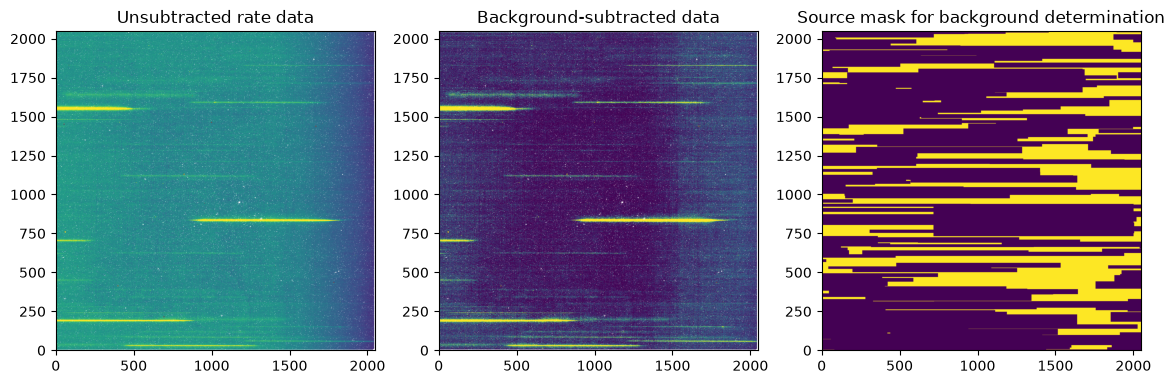

In [58]:
# Show the dispersed data before and after background subtraction. Also show the mask used
# for the background construction.
f, a = plt.subplots(ncols=3, nrows=1, figsize=(14, 10))
a[0].imshow(rate_model.data, origin='lower', vmin=0, vmax=0.4)
a[0].set_title('Unsubtracted rate data')
a[1].imshow(bsub_model.data, origin='lower', vmin=0, vmax=0.1)
a[1].set_title('Background-subtracted data')
a[2].imshow(bsub_model.mask, origin='lower', vmin=0, vmax=0.7)
a[2].set_title('Source mask for background determination')
plt.show()

Let's go back to the source catalog, and look at the distribution of `isophotal_abmag` values in the image relative to the cutoff magnitude that we specified. Sources to the right of the vertical dashed line were included as background pixels when determining the mean background value in the image.

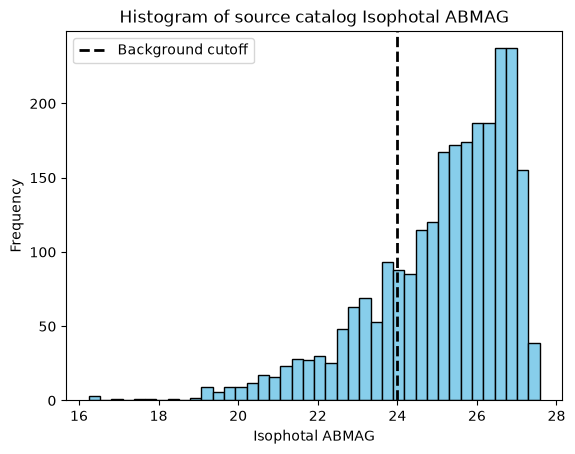

In [59]:
fig, ax = plt.subplots()

ax.hist(cat['isophotal_abmag'], bins=40, edgecolor="black", color="skyblue")
ax.axvline(x=24.0, color="black", linestyle="--", linewidth=2, label="Background cutoff")

ax.set_title("Histogram of source catalog Isophotal ABMAG")
ax.set_xlabel("Isophotal ABMAG")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()

#### 2D and 1D spectra (*_cal.fits and *_x1d.fits)

In WFSS data there can be many sources of interest to look at. In this visualization we examine, for five selected sources, the source as it appears in the i2d image, two example grism `*_cal.fits` 2-D spectral cutouts (if available, otherwise they may appear blank), and the level 2 `*_x1d.fits` 1-D extracted spectra for all grism dithers where available. With the contamination step currently turned off, the contamination can be easily visible when comparing the 1-D and 2-D spectra of the two grisms.

Note that the `*_cal.fits` data for GRISMC are transposed so that the dispersion direction is along the -x axis. For both GRISMC and GRISMR where necessary, the x axis is then flipped so that wavelength will always be increasing to the right.

In [60]:
# Select sources to show in the example figure below, using RA, Dec.
# These sources, from the demo data, were selected manually by examining the i2d file
ra_decs = [(214.967375, 52.926306),
           (214.990833, 52.905944),
           (214.990667, 52.919932),
           (214.95887105, 52.90098716),
           (214.91440591, 52.8759353)
           ]

In [61]:
# Generate a list of sources and the files needed to examine them below
if doviz:
    # Grab the spec2 x1d output products
    spec2_x1d_files = sorted(glob.glob(os.path.join(spec2_dir, '*nrc*_x1d.fits*')))

    # If there are multiple blocking filters, pick one for illustration
    spec2_unique_filters = np.unique([fits.getval(x1d, 'FILTER') for x1d in spec2_x1d_files])
    filter_x1ds = [x1d for x1d in spec2_x1d_files if fits.getval(x1d, 'FILTER') == spec2_unique_filters[0]]

    if demo_mode:
        # Find the source catalog for this set of filters
        source_catfile = os.path.join(image3_dir, fits.getval(filter_x1ds[0], 'SCATFILE'))

        # For each of the sources defined in ra_decs, find the source ID for the closest
        # target in the source catalog output from the detector1 pipeline
        sources = [find_closest_source_id(ra, dec, source_catfile) for ra, dec in ra_decs]
        nsources = len(sources)
    else:
        # Or grab some sources from the first x1d file
        nsources = 5  # 100 sources are extracted by default
        source_offset = 3  # offsetting what nsources to plot to avoid extra bright sources
        with fits.open(filter_x1ds[0]) as temp_x1d:
            sources = temp_x1d[1].data['SOURCE_ID'][source_offset:nsources+source_offset]

In [62]:
# Print the source numbers corresponding to the RA, Dec values above
sources

[np.int32(2339), np.int32(2163), np.int32(662), np.int32(2264), np.int32(911)]

##### Example spec2 output figure

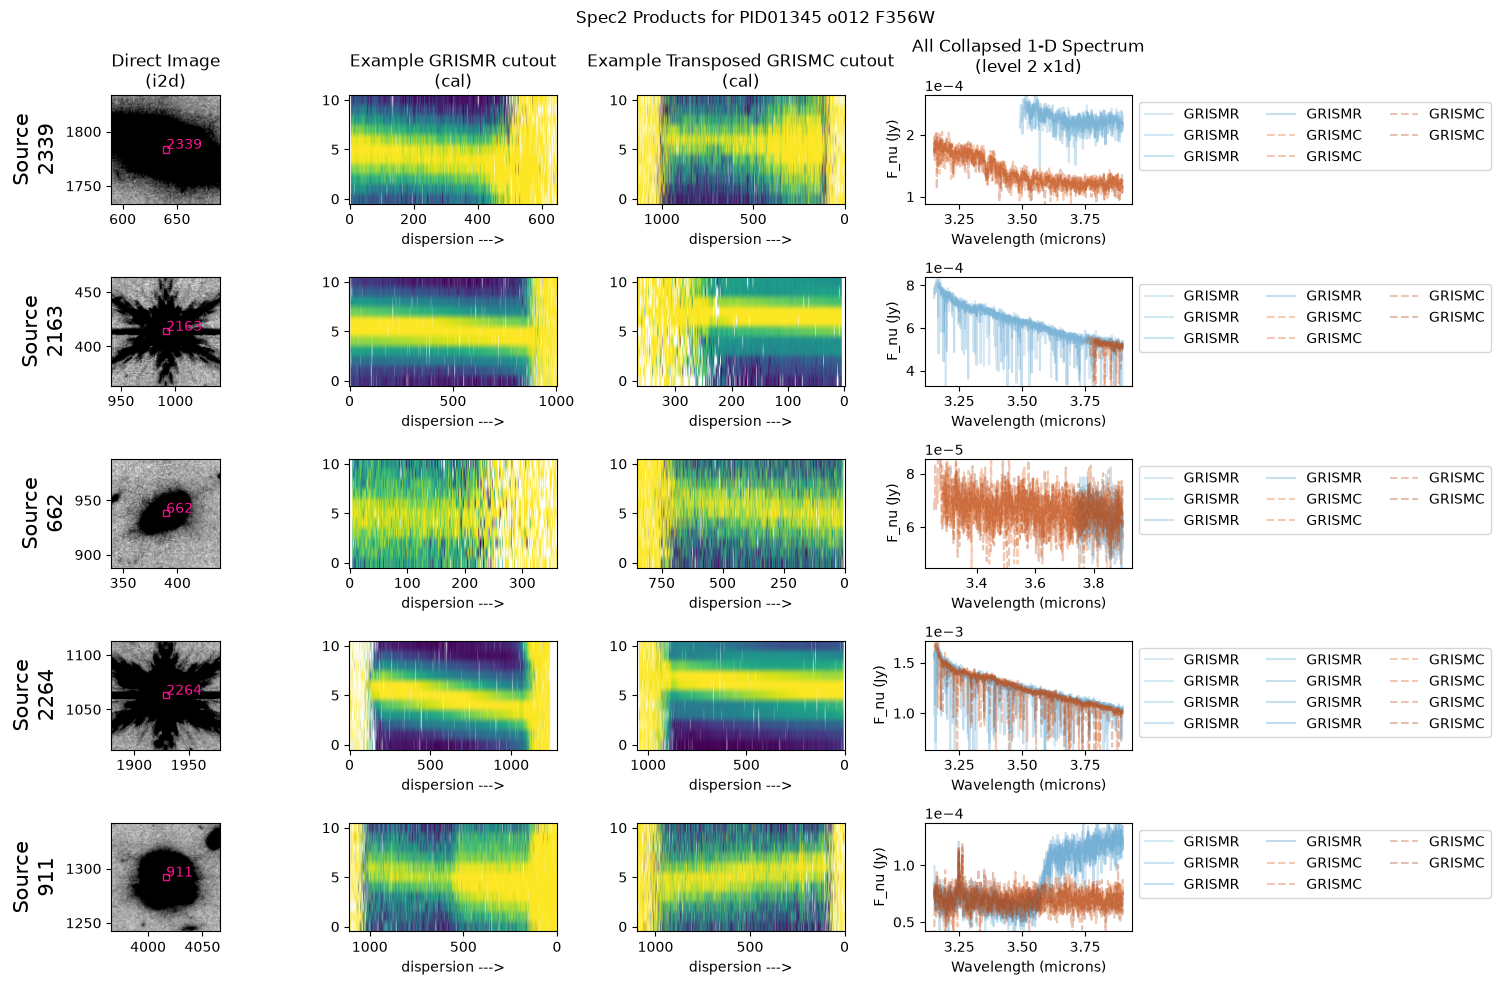

In [63]:
# For each source, look at the source as identified by the source catalog in the i2d image,
# the two grism cal files, and the x1d files
if doviz:
    # Set up the figure
    cols = 4
    rows = nsources
    fig = plt.figure(figsize=(15, 4*(rows/2)))
    fig.suptitle(f"Spec2 Products for PID{program} o{sci_observtn} {spec2_unique_filters[0]}")

    # Color lists for 1D spectra plots
    blues = plt.cm.Blues(np.linspace(0.45, 0.9, len(filter_x1ds)))
    oranges = plt.cm.Oranges(np.linspace(0.45, 0.9, len(filter_x1ds)))

    # Simple records of which files source IDs are found within, and which extensions
    x1d_status = []
    grismr_cal_status = []
    grismc_cal_status = []
    
    # Loop through the different sources to plot; one per row
    for nsource, source_id in enumerate(sources):
        # Only plot a single cal file cutout for each grism
        plot_grismr = True
        plot_grismc = True

        # Set up the subplots for a single source
        ypos = nsource
        ax_i2d = plt.subplot2grid((rows, cols), (ypos, 0)) 
        ax_cal_r = plt.subplot2grid((rows, cols), (ypos, 1)) 
        ax_cal_c = plt.subplot2grid((rows, cols), (ypos, 2)) 
        ax_x1d = plt.subplot2grid((rows, cols), (ypos, 3))
    
        source_fluxes = []  # Save the source flux to set the plot limits
                
        # Plot all of the 1-D spectra from the x1d files
        for nfile, x1dfile in enumerate(filter_x1ds):

            ax_x1d, catname, source_fluxes, grism, status = plot_spectrum(x1dfile, source_id, source_fluxes, ax_x1d,
                                                                          image3_dir, colors=[blues[nfile], oranges[nfile]],
                                                                          legend=False)
            x1d_status.append(status)
            
            # Plot the direct image of the source based on the source number from the source catalog
            if nfile == 0:
                ax_i2d = plot_i2d_plus_source(catname, source_id, ax_i2d)
            
            # Plot one example cal image from GRISMR
            if plot_grismr and grism == 'GRISMR':
                ax_cal_r, source_found, status = plot_spec2_cal(x1dfile, source_id, ax_cal_r)
                grismr_cal_status.append(status)
                if source_found:
                    plot_grismr = False
                
            # Plot one example cal image from GRISMC
            if plot_grismc and grism == 'GRISMC':
                ax_cal_c, source_found, status = plot_spec2_cal(x1dfile, source_id, ax_cal_c)
                grismc_cal_status.append(status)
                if source_found:
                    plot_grismc = False
        
        if len(source_fluxes):
            # Try to avoid excessively noisy points when setting plot limits
            lo, hi = np.nanpercentile(source_fluxes, [1, 99])  # ignores bottom/top 1%

            # Add a little padding so the continuum isn't hugging the edges
            pad = 0.1 * (hi - lo)
            ax_x1d.set_ylim(lo - pad, hi + pad)

            ax_x1d.legend(bbox_to_anchor=(1, 1), ncols=np.ceil(len(filter_x1ds)/6))
        
        # Add labels to the subplots
        if nsource == 0:
            ax_cal_r.set_title('Example GRISMR cutout\n(cal)')
            ax_cal_c.set_title('Example Transposed GRISMC cutout\n(cal)')
            ax_i2d.set_title('Direct Image\n(i2d)')
            ax_x1d.set_title('All Collapsed 1-D Spectrum\n(level 2 x1d)')
            
        ax_i2d.set_ylabel(f'Source\n{source_id}', fontsize=15)
        ax_cal_r.set_xlabel('dispersion --->')
        ax_cal_c.set_xlabel('dispersion --->')
        ax_x1d.set_xlabel('Wavelength (microns)')
        ax_x1d.set_ylabel('F_nu (Jy)')
        ax_x1d.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))  # force scientific notation for the spectra

    fig.tight_layout()

Notes on which files and extensions each source was found in.

In [64]:
x1d_status

['Source 2339 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_spec/jw01345012001_02101_00001_nrcalong_x1d.fits',
 'Source 2339 not found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_spec/jw01345012001_02101_00001_nrcblong_x1d.fits',
 'Source 2339 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_spec/jw01345012001_02101_00002_nrcalong_x1d.fits',
 'Source 2339 not found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_spec/jw01345012001_02101_00002_nrcblong_x1d.fits',
 'Source 2339 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_spec/jw01345012001_0210

In [65]:
grismr_cal_status

[['Extension 15 in jw01345012001_02101_00001_nrcalong_cal.fits contains the data for source 2339 from our catalog'],
 ['Extension 8 in jw01345012001_02101_00001_nrcalong_cal.fits contains the data for source 2163 from our catalog'],
 ['Extension 36 in jw01345012001_02101_00001_nrcalong_cal.fits contains the data for source 662 from our catalog'],
 ['Extension 1 in jw01345012001_02101_00001_nrcalong_cal.fits contains the data for source 2264 from our catalog'],
 ['Source 911 not present in jw01345012001_02101_00001_nrcalong_cal.fits'],
 ['Extension 36 in jw01345012001_02101_00001_nrcblong_cal.fits contains the data for source 911 from our catalog']]

In [66]:
grismc_cal_status

[['Extension 15 in jw01345012001_07101_00001_nrcalong_cal.fits contains the data for source 2339 from our catalog'],
 ['Extension 8 in jw01345012001_07101_00001_nrcalong_cal.fits contains the data for source 2163 from our catalog'],
 ['Extension 29 in jw01345012001_07101_00001_nrcalong_cal.fits contains the data for source 662 from our catalog'],
 ['Extension 1 in jw01345012001_07101_00001_nrcalong_cal.fits contains the data for source 2264 from our catalog'],
 ['Source 911 not present in jw01345012001_07101_00001_nrcalong_cal.fits'],
 ['Extension 29 in jw01345012001_07101_00001_nrcblong_cal.fits contains the data for source 911 from our catalog']]








<hr style="border:1px solid gray"> </hr>

## 11. Spec3 Pipeline
------------------

NIRCam WFSS data are minimally processed through the [Spec3 stage of the pipeline](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_spec3.html) to combine calibrated data from multiple dithers within an observation. The spec3 products are unique for a specific grism and blocking filter combination; data is not combined across grisms, even for the same sources. Each output `*_x1d.fits` file created in the [extract_1d](https://jwst-pipeline.readthedocs.io/en/latest/jwst/extract_1d/description.html) step and `*_c1d.fits` file created in the [combine_1d](https://jwst-pipeline.readthedocs.io/en/latest/jwst/combine_1d/description.html) step contain data for a single grism/filter combination, with all of the extracted sources contained within that file.

In [67]:
time_spec3 = time.perf_counter()

In [68]:
# Find the cal.fits files
sstring = os.path.join(spec2_dir, 'jw*cal.fits')
spec2_cal_files = sorted(glob.glob(sstring))
for ii, cal_relpath in enumerate(spec2_cal_files):
    spec2_cal_files[ii] = os.path.abspath(cal_relpath)
spec2_cal_files = np.array(spec2_cal_files)

print(f'Found {str(len(spec2_cal_files))} grism spectroscopy cal files to process for level 3')

Found 16 grism spectroscopy cal files to process for level 3


### Create Spec3 Association Files

There will be one spec3 association per blocking filter and grism combination. Each association will contain all of the extracted 2-D spectra (`*_cal.fits` files) for that filter and grism combination. For each source, the Spec3 pipeline will coadd the individual spectra from these files into a single spectrum. Fro example, if using only one blocking filter (e.g., F356W) with both grisms (GRISMR & GRISMC), there will be two Spec3 association files, each containing all of the corresponding `*_cal.fits` files to combine.

Like with Image3 and Spec2 before, we will be creating Image3 associations by providing a [list of exposures](https://jwst-pipeline.readthedocs.io/en/latest/jwst/associations/asn_from_list.html) that we have processed through the pipeline and saved in separate directories rather than downloading directly from MAST or using the [pool files](https://jwst-pipeline.readthedocs.io/en/latest/jwst/associations/asn_generate.html). Note that the Spec3 output products will have a rootname that is specified by the `product_name` in the association file. In the cell below, we create and save the association files, which will have filenames that end with `_spec3_asn.json`.

In [69]:
# Create Level 3 Associations for each pupil (blocking filter) type
if dospec3:

    # Parameters to be used for the spec3 association creation
    spec3_pid = str(program) # Associations are only set up to combine for the same program & observation
    spec3_obs = str(sci_observtn) # Associations are only set up to combine for the same program & observation
    spec3_ins = 'NIRCAM'

    # Identify the unique filters & grisms used for the WFSS cal files
    spec3_dict = {}
    spec3_dict['PUPIL'] = np.array([fits.getval(cf, 'PUPIL') for cf in spec2_cal_files])
    spec3_dict['FILTER'] = np.array([fits.getval(cf, 'FILTER') for cf in spec2_cal_files])
    spec3_dict['PATHNAMES'] = np.array(spec2_cal_files)

    spec3_df = pd.DataFrame(spec3_dict)

    # Loop over unique crossing filter values
    for spec3_filter in spec3_df['FILTER'].unique():        
        # Loop over the grisms
        for spec3_grism in spec3_df['PUPIL'].unique():
            # Find the files specific to each of the filters & grisms
            spec3_files = spec3_df[(spec3_df['FILTER'] == spec3_filter) & (spec3_df['PUPIL'] == spec3_grism)]['PATHNAMES']

            # Build the association names to match the default names from the pipeline
            product_name = f"jw{spec3_pid}-o{spec3_obs}_{spec3_ins}_{spec3_grism}-{spec3_filter}".lower()
            spec3_asn_filename = product_name + '_spec3_asn.json'
    
            spec3_association = asn_from_list.asn_from_list(spec3_files, rule=DMS_Level3_Base,
                                                            product_name=product_name)
    
            spec3_association.data['asn_type'] = 'spec3'
            spec3_association.data['program'] = spec3_pid
    
            # Format association as .json file
            _, serialized = spec3_association.dump(format="json")

            # Write out association file
            association_spec3 = os.path.join(sci_dir, spec3_asn_filename)
            with open(association_spec3, "w") as fd:
                fd.write(serialized)

            print(f'Writing spec3 association: {association_spec3}')

Writing spec3 association: /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/jw01345-o012_nircam_grismr-f356w_spec3_asn.json
Writing spec3 association: /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/jw01345-o012_nircam_grismc-f356w_spec3_asn.json


/home/runner/micromamba/envs/ci-env/lib/python3.13/site-packages/jwst/associations/association.py:232: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)


Take a quick look at the contents of the first spec3 association file to get a feel for its contents.

In [70]:
if dospec3:
    spec3_asns = glob.glob(os.path.join(sci_dir, "*spec3_asn.json"))
    
    # open the image3 association to look at
    spec3_asn_data = json.load(open(spec3_asns[0]))
    print(f'asn_type : {spec3_asn_data["asn_type"]}')
    print(f'code_version : {spec3_asn_data["code_version"]}')
    
    # in particular, take a closer look at the product filenames with the association file:
    for product in spec3_asn_data['products']:
        for key, value in product.items():
            if key == 'members':
                print(f"{key}:")
                for member in value:
                    print(f"    {member['expname']} {member['exptype']}")
            else:
                print(f"{key}: {value}")

asn_type : spec3
code_version : 3.0.0
name: jw01345-o012_nircam_grismc-f356w
members:
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_spec/jw01345012001_07101_00001_nrcalong_cal.fits science
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_spec/jw01345012001_07101_00001_nrcblong_cal.fits science
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_spec/jw01345012001_07101_00002_nrcalong_cal.fits science
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_spec/jw01345012001_07101_00002_nrcblong_cal.fits science
    /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage2_spec/jw013450120

### Run Spec3

In the spec3 pipeline, 1-D spectra are created for each source from the input `*_cal.fits` files. These spectra are saved into level 3 `*_x1d.fits` files. An x1d.fits file contains one extension for each cal.fits file used as input. Each extension contains a table with the 1D spectra from all sources in that cal.fits file.

For each source, the associated 1-D spectra are then combined into a single 1-D spectrum and saved into a `*_c1d.fits` file. The c1d.fits file contains a single extension with a table of the spectra for all sources. The parameters in each of the [Spec3 steps](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_spec3.html) can be modified from the default values, including overwriting reference files that are used during this stage. This dictionary of the modified parameters for each of the steps is then fed into the `steps` parameter of the `Spec3Pipeline` call. The syntax for modifying some of these parameters is below.

In [71]:
# Set up a dictionary to define how the Spec3 pipeline should be configured.

# this sets up any entry to spec3dict to be a dictionary itself
spec3dict = defaultdict(dict)

# -----------------------------Set step parameters------------------------------

# Overrides for whether or not certain steps should be skipped (example).
# spec3dict['pixel_replace']['skip'] = True

In [72]:
spec3_dir

'/home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec'

In [73]:
# Run Stage 3
if dospec3:
    for spec3_asn in spec3_asns:
        # spec3 ignores the specified output dir. Change to the directory we want the
        # output to be in
        os.chdir(spec3_dir)  
        spec3 = Spec3Pipeline.call(spec3_asn, output_dir=spec3_dir, steps=spec3dict, save_results=True)
        # change back into the directory you started in
        os.chdir(cwd) 
else:
    print('Skipping Spec3 processing')

2026-09-29 20:00:49,207 - stpipe.step - INFO - Spec3Pipeline instance created.


2026-09-29 20:00:49,208 - stpipe.step - INFO - AssignMTWcsStep instance created.


2026-09-29 20:00:49,209 - stpipe.step - INFO - MasterBackgroundStep instance created.


2026-09-29 20:00:49,209 - stpipe.step - INFO - OutlierDetectionStep instance created.


2026-09-29 20:00:49,210 - stpipe.step - INFO - AdaptiveTraceModelStep instance created.


...

2026-09-29 20:02:54,493 - jwst.pipeline.calwebb_spec3 - INFO - Saving the final x1d product as jw01345-o012_nircam_grismr-f356w_x1d.fits.


2026-09-29 20:02:54,670 - jwst.pipeline.calwebb_spec3 - INFO - Saving the final c1d product as jw01345-o012_nircam_grismr-f356w_c1d.fits.


2026-09-29 20:02:54,710 - jwst.pipeline.calwebb_spec3 - INFO - Ending calwebb_spec3


2026-09-29 20:02:54,746 - stpipe.step - INFO - Step Spec3Pipeline done


2026-09-29 20:02:54,747 - jwst.stpipe.core - INFO - Results used jwst version: 3.0.0


In [74]:
# Print out the time benchmark
time_spec3_end = time.perf_counter()
print(f"Runtime for Spec3: {(time_spec3_end - time_spec3)/60:0.0f} minutes")

Runtime for Spec3: 2 minutes


<hr style="border:1px solid gray"> </hr>

## 12. Understanding Spec3 Output Products
------------------
The outputs of spec3 are `*_x1d.fits` and `*_c1d.fits` files. Here we do a quick look into some important parts of these files.

Each extension of the spec3 `*_x1d.fits` files contains the extracted, 1-D spectra for an individual dither for a single grism, filter, and extracted order combination. The specific filenames and extracted order can be verified with the `FILENAME` and `SPORDER` keywords in the header of each extension respectively. Within the extension, each of the extracted sources across all dithers are listed, with the values being empty if the particular dither did not contain data for that source. Also contained within each extension is information related to the extraction of a particular source, including the extents and starting size of the extraction box in the full reference frame. More information about the columns contained withing the `*_x1d.fits` files can be found in the [x1d filetype documentation](https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/science_products.html#extracted-1-d-spectroscopic-data-x1d-and-x1dints).

In [75]:
# Print a list of the spec3 output x1d and c1d files
spec3_x1ds = sorted(glob.glob(os.path.join(spec3_dir, "*x1d.fits")))
print('spec3 x1d files:')
for x1d_filename in spec3_x1ds:
    print(f"   {os.path.basename(x1d_filename)}")

spec3_c1ds = sorted(glob.glob(os.path.join(spec3_dir, "*c1d.fits")))
print('spec3 c1d files:')
for c1d_filename in spec3_c1ds:
    print(f"   {os.path.basename(c1d_filename)}")

spec3 x1d files:
   jw01345-o012_nircam_grismc-f356w_x1d.fits
   jw01345-o012_nircam_grismr-f356w_x1d.fits
spec3 c1d files:
   jw01345-o012_nircam_grismc-f356w_c1d.fits
   jw01345-o012_nircam_grismr-f356w_c1d.fits


In [76]:
sample_x1d = fits.open(spec3_x1ds[0])

In [77]:
# Show the RA, Dec, and Source ID values for all sources
# in one extension of one of the x1d files
print('         RA                 Dec      Source ID')
for ii in range(20):
    print(sample_x1d[1].data['SOURCE_RA'][ii], sample_x1d[1].data['SOURCE_DEC'][ii], sample_x1d[1].data['SOURCE_ID'][ii])

         RA                 Dec      Source ID
214.99071891426155 52.919937838530046 662
nan nan 752
214.91440590682512 52.87593529735008 911
214.94314199108138 52.91030411711324 1299
214.95733864855177 52.92145103458002 1334
214.9209217744617 52.91691830585203 1935
214.88681776043978 52.89213153002084 1938
214.92041978202667 52.8518150897347 2130
214.92087967090544 52.85241342170964 2131
214.91386489697842 52.85203666184642 2136
214.95475449584077 52.87656911536902 2145
214.98546510843585 52.8977754501676 2154
214.990840812769 52.905988787384075 2163
214.97789988437134 52.89703627583545 2170
214.92058876056026 52.865867588902596 2224
214.91994949467954 52.866867046021305 2227
214.95885971325654 52.90097416501405 2264
214.92322940072475 52.8821394356281 2295
214.9645255628833 52.92416731299723 2338
214.9674159628111 52.926264174030294 2339


In [78]:
# Print information about the structure of the x1d files by reading in the first one
if doviz:
    sample_x1d = fits.open(spec3_x1ds[0])

    print("***Format of the level 3 x1d file:")
    sample_x1d.info()

    print("\n***cal files used to create this level 3 x1d file:")
    for ext in range(len(sample_x1d))[1:-1]:
        print(f"Extension {ext}: {sample_x1d[ext].header['FILENAME']}, order {sample_x1d[ext].header['SPORDER']}")

    print("\n***Columns contained in each extension of the level 3 x1d file:")
    print(sample_x1d[1].data.columns)

***Format of the level 3 x1d file:
Filename: /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismc-f356w_x1d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     288   ()      
  1  EXTRACT1D     1 BinTableHDU    123   21R x 29C   [J, 1136D, 1136D, 1136D, 1136D, 1136D, 1136D, 1136D, 1136D, 1136D, 1136D, 1136D, 1136J, 1136D, 1136D, 1136D, 1136D, 1136D, 1136D, J, 20A, D, D, D, D, J, J, J, J]   
  2  EXTRACT1D     2 BinTableHDU    122   21R x 29C   [J, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, 1135J, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, J, 20A, D, D, D, D, J, J, J, J]   
  3  EXTRACT1D     3 BinTableHDU    122   21R x 29C   [J, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, 1135J, 1135D, 1135D, 1135D, 1135D, 1135D, 1135D, J, 20A, D, D, D, D, J, J, J, J]   
  4  EXT


***cal files used to create this level 3 x1d file:
Extension 1: jw01345012001_07101_00001_nrcalong_cal.fits, order 1
Extension 2: jw01345012001_07101_00002_nrcalong_cal.fits, order 1
Extension 3: jw01345012001_07101_00003_nrcalong_cal.fits, order 1
Extension 4: jw01345012001_07101_00004_nrcalong_cal.fits, order 1

***Columns contained in each extension of the level 3 x1d file:
ColDefs(
    name = 'SOURCE_ID'; format = 'J'
    name = 'WAVELENGTH'; format = '1136D'; unit = 'um'; dim = '(1136)'
    name = 'FLUX'; format = '1136D'; unit = 'Jy'; dim = '(1136)'
    name = 'FLUX_ERROR'; format = '1136D'; unit = 'Jy'; dim = '(1136)'
    name = 'FLUX_VAR_POISSON'; format = '1136D'; unit = 'Jy^2'; dim = '(1136)'
    name = 'FLUX_VAR_RNOISE'; format = '1136D'; unit = 'Jy^2'; dim = '(1136)'
    name = 'FLUX_VAR_FLAT'; format = '1136D'; unit = 'Jy^2'; dim = '(1136)'
    name = 'SURF_BRIGHT'; format = '1136D'; unit = 'MJy/sr'; dim = '(1136)'
    name = 'SB_ERROR'; format = '1136D'; unit = 'MJy/sr';

The `*_c1d.fits` files contain combined extensions of the same order in the spec3 `*_x1d.fits` files into a single file. The source numbers in the `*_c1d.fits` match those in the level 3 `*_x1d.fits` files. More information about the columns contained within the `*_c1d.fits` files can be found in the [c1d filetype documentation](https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/science_products.html#combined-1-d-spectroscopic-data-c1d).

In [79]:
# Print information about the structure of the c1d files by reading in the first one
if doviz:
    sample_c1d = fits.open(spec3_c1ds[0])

    print("***Format of the c1d file:")
    sample_c1d.info()

    print("\n***Extracted orders contained in the c1d file:")
    for ext in range(len(sample_c1d))[1:-1]:
        print(f"Extension {ext}: order {sample_c1d[ext].header['SPORDER']}")
    
    print("\n***Columns contained in each extension of the c1d file:")
    print(sample_c1d[1].data.columns)

***Format of the c1d file:
Filename: /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismc-f356w_c1d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     293   ()      
  1  COMBINE1D     1 BinTableHDU     55   21R x 13C   [J, 1508D, 1508D, 1508D, 1508D, 1508D, 1508J, 1508D, 1508D, J, 20A, D, D]   
  2  ASDF          1 BinTableHDU     11   1R x 1C   [23528B]   



***Extracted orders contained in the c1d file:
Extension 1: order 1

***Columns contained in each extension of the c1d file:
ColDefs(
    name = 'SOURCE_ID'; format = 'J'
    name = 'WAVELENGTH'; format = '1508D'; unit = 'um'; dim = '(1508)'
    name = 'FLUX'; format = '1508D'; unit = 'Jy'; dim = '(1508)'
    name = 'ERROR'; format = '1508D'; unit = 'Jy'; dim = '(1508)'
    name = 'SURF_BRIGHT'; format = '1508D'; unit = 'MJy/sr'; dim = '(1508)'
    name = 'SB_ERROR'; format = '1508D'; unit = 'MJy/sr'; dim = '(1508)'
    name = 'DQ'; format = '1508J'; bzero = 2147483648; dim = '(1508)'
    name = 'WEIGHT'; format = '1508D'; dim = '(1508)'
    name = 'N_INPUT'; format = '1508D'; dim = '(1508)'
    name = 'N_ALONGDISP'; format = 'J'; bzero = 2147483648
    name = 'SOURCE_TYPE'; format = '20A'
    name = 'SOURCE_RA'; format = 'D'; unit = 'deg'
    name = 'SOURCE_DEC'; format = 'D'; unit = 'deg'
)


Digging a little bit further into the different source IDs and how those are handled, you can see that in each extension the source IDs are now identical, which is not always the case in the level 2 x1d files.

In [80]:
if doviz:
    for ext in np.arange(len(sample_x1d))[1:-1]:
        print(f"Extension {ext}: {sample_x1d[ext].header['FILENAME']}, Order {sample_x1d[ext].header['SPORDER']}")
        print("  Sources:\n", sample_x1d[ext].data['SOURCE_ID'])

Extension 1: jw01345012001_07101_00001_nrcalong_cal.fits, Order 1
  Sources:
 [ 662  752  911 1299 1334 1935 1938 2130 2131 2136 2145 2154 2163 2170
 2224 2227 2264 2295 2338 2339 2411]
Extension 2: jw01345012001_07101_00002_nrcalong_cal.fits, Order 1
  Sources:
 [ 662  752  911 1299 1334 1935 1938 2130 2131 2136 2145 2154 2163 2170
 2224 2227 2264 2295 2338 2339 2411]
Extension 3: jw01345012001_07101_00003_nrcalong_cal.fits, Order 1
  Sources:
 [ 662  752  911 1299 1334 1935 1938 2130 2131 2136 2145 2154 2163 2170
 2224 2227 2264 2295 2338 2339 2411]
Extension 4: jw01345012001_07101_00004_nrcalong_cal.fits, Order 1
  Sources:
 [ 662  752  911 1299 1334 1935 1938 2130 2131 2136 2145 2154 2163 2170
 2224 2227 2264 2295 2338 2339 2411]


If a source was not extracted for a given extension, the values will be filled in with a value of "0" or "nan". The column `N_ALONGDISP` lists the number of pixel columns or rows in the dispersion direction that were included in the spectral extraction. This can be a useful tracer for finding sources that were not extracted as they will have a value of zero.

In [81]:
# Check the number of pixel rows or columns in the extracted trace at extension 1 (first file)
# as an example of what a source looks like if it's not extracted
ext = 1

trace_len = sample_x1d[ext].data['N_ALONGDISP']
source_id = sample_x1d[ext].data['SOURCE_ID']

trace_df = pd.DataFrame({"Source_ID": sample_x1d[ext].data['SOURCE_ID'],
                         "Trace_Length": sample_x1d[ext].data['N_ALONGDISP']
                         }
                        )
trace_df

,Source_ID,Trace_Length
0,662,851
1,752,0
2,911,1098
3,1299,1078
4,1334,1095
5,1935,586
6,1938,552
7,2130,212
8,2131,294
9,2136,365


In [82]:
# Search for any sources that were not extracted (N_ALONGDISP == 0)
# Using the demo data and extracting only the 10 brightest sources, we
# see that all sources are present in every *_cal.fits file and were extracted.
wh_no_source = np.where(sample_x1d[ext].data['N_ALONGDISP'] == 0)[0]
print(f"{sample_x1d[ext].header['FILENAME']} does not extract the following sources:")
print(f"  {sample_x1d[ext].data['SOURCE_ID'][wh_no_source]}")
if len(wh_no_source) > 0:
    print("Different column defaults when a source is not extracted:")
    for colname in sample_x1d[ext].data.names:
        print(f"  {colname} : {np.unique(sample_x1d[ext].data[colname][wh_no_source[0]])}")

jw01345012001_07101_00001_nrcalong_cal.fits does not extract the following sources:
  [752]
Different column defaults when a source is not extracted:
  SOURCE_ID : [752]
  WAVELENGTH : [nan]
  FLUX : [nan]
  FLUX_ERROR : [nan]
  FLUX_VAR_POISSON : [nan]
  FLUX_VAR_RNOISE : [nan]
  FLUX_VAR_FLAT : [nan]
  SURF_BRIGHT : [nan]
  SB_ERROR : [nan]
  SB_VAR_POISSON : [nan]
  SB_VAR_RNOISE : [nan]
  SB_VAR_FLAT : [nan]
  DQ : [1]
  BACKGROUND : [nan]
  BKGD_ERROR : [nan]
  BKGD_VAR_POISSON : [nan]
  BKGD_VAR_RNOISE : [nan]
  BKGD_VAR_FLAT : [nan]
  NPIXELS : [nan]
  N_ALONGDISP : [0]
  SOURCE_TYPE : ['']
  SOURCE_XPOS : [nan]
  SOURCE_YPOS : [nan]
  SOURCE_RA : [nan]
  SOURCE_DEC : [nan]
  EXTRACT2D_XSTART : [0]
  EXTRACT2D_YSTART : [0]
  EXTRACT2D_XSTOP : [0]
  EXTRACT2D_YSTOP : [0]


### Visualize Spec3 Outputs

To compare with the Spec2 output products above, we look at the same sources, plotting instead the final `*_c1d.fits` files for each grism. We again show the `*_i2d.fits` image for a specific source, followed by the level 3 `*_x1d.fits` individual spectra for each of the two grisms (if both were used--if one is not used that column will be blank), followed by the `*_c1d.fits` combined spectrum for each of the grisms if available.

In [83]:
# Look at the i2d images, the level 3 x1d spectra, and the combined c1d spectra for both grisms
# for several sources
# Grab the files & sources to look at
if doviz:
    # Grab the c1d files to plot
    spec3_c1ds = np.sort(glob.glob(os.path.join(spec3_dir, "*c1d.fits")))

    # If there are multiple blocking filters, pick one for illustration
    unique_filters = np.unique([fits.getval(c1d, 'FILTER') for c1d in spec3_c1ds])
    filter_c1ds = [c1d for c1d in spec3_c1ds if fits.getval(c1d, 'FILTER') == unique_filters[0]]
    
    if demo_mode:
        # Find the source catalog for this set of filters
        source_catfile = os.path.join(image3_dir, fits.getval(filter_x1ds[0], 'SCATFILE'))
        sources = [find_closest_source_id(ra, dec, source_catfile) for ra, dec in ra_decs]
        nsources = len(sources)
    else:
        # Or grab some sources from the first x1d file
        nsources = 5  # 100 Sources are extracted by default
        source_offset = 3  # Offsetting what nsources to plot to avoid extra bright sources
        with fits.open(pupil_c1ds[0]) as temp_c1d:
            sources = temp_c1d[1].data['SOURCE_ID'][source_offset:nsources+source_offset]    

In [84]:
filter_c1ds

[np.str_('/home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismc-f356w_c1d.fits'),
 np.str_('/home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismr-f356w_c1d.fits')]

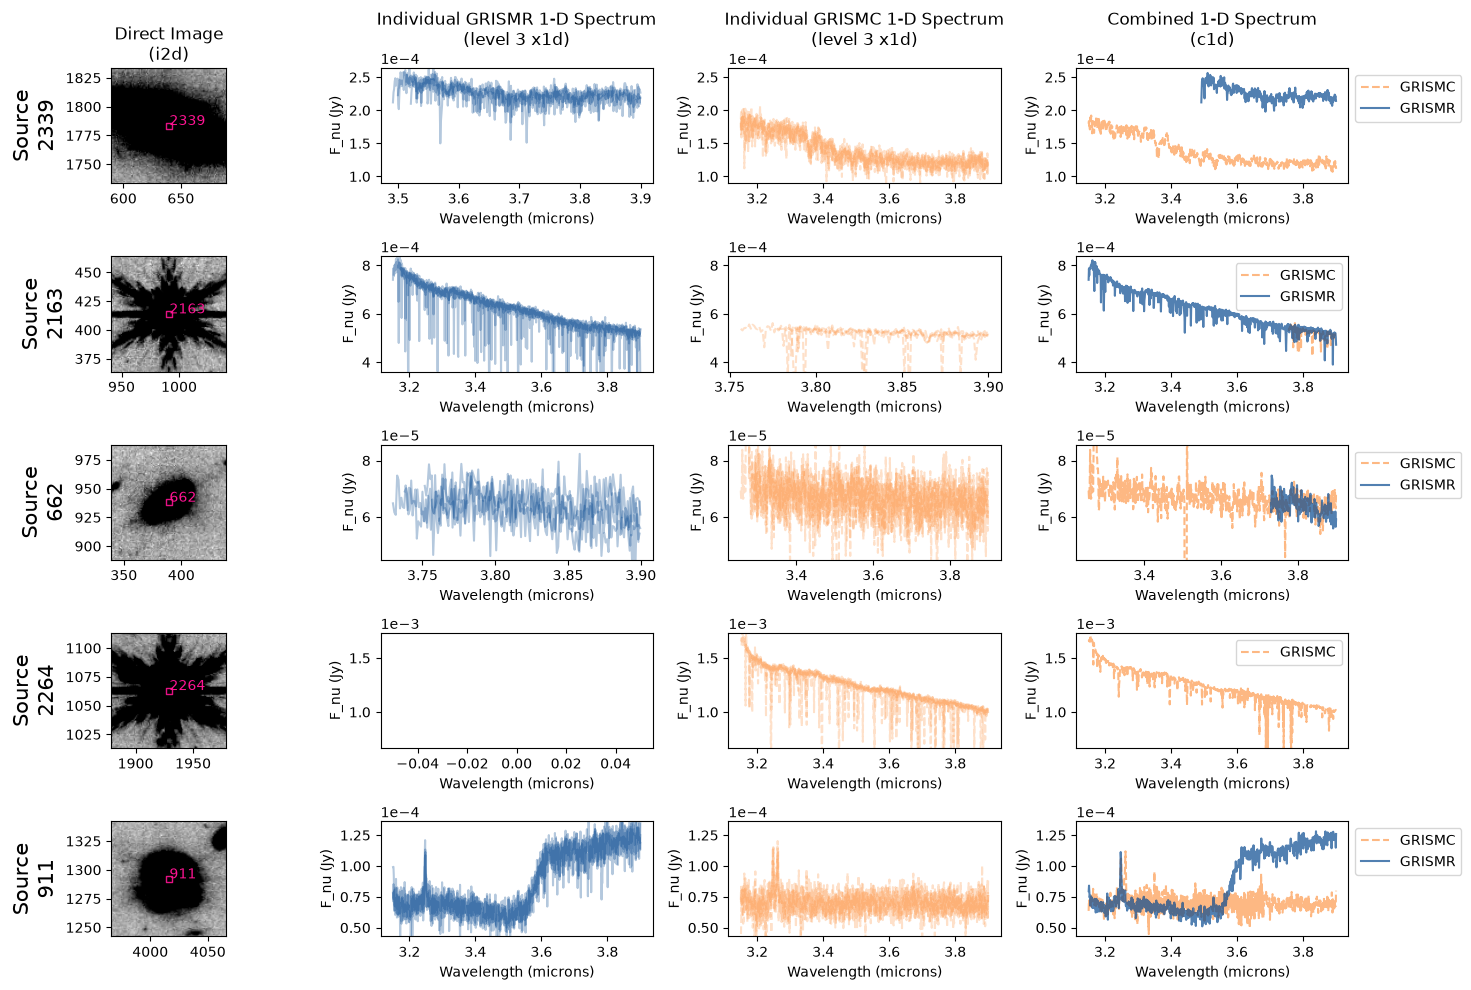

In [85]:
# Look at the i2d images, the level 3 x1d spectra, and the combined c1d spectra
# for both grisms for the selected sources
if doviz:
    # Set up the figure
    cols = 4
    rows = nsources
    fig_c1d = plt.figure(figsize=(15, 4*(rows/2)))

    # Color lists for 1D spectra plots
    l3_blues = plt.cm.Blues(np.linspace(0.45, 0.9, len(filter_c1ds)))
    l3_oranges = plt.cm.Oranges(np.linspace(0.45, 0.9, len(filter_c1ds)))

    # Simple status notes
    l3_c1d_status = []
    l3_x1d_status = []

    # Loop through the different sources to plot; one per row
    for nsource, source_id in enumerate(sources):

        # setting up the subplots for a single source
        ypos = nsource
        ax_i2d = plt.subplot2grid((rows, cols), (ypos, 0)) 
        ax_x1d_r = plt.subplot2grid((rows, cols), (ypos, 1))
        ax_x1d_c = plt.subplot2grid((rows, cols), (ypos, 2))
        ax_c1d = plt.subplot2grid((rows, cols), (ypos, 3))
    
        source_fluxes = []  # Save the source flux to set the plot limits
        x1dr_source_fluxes = []
        x1dc_source_fluxes = []

        # Plot all of the 1-D combined spectra from the c1d files
        for nfile, c1dfile in enumerate(filter_c1ds):
            
            # Plot the c1d spectra
            ax_c1d, catname, c1d_source_fluxes, grism, status = plot_spectrum(c1dfile, source_id, source_fluxes, ax_c1d, image3_dir,
                                                                              colors=[l3_blues[nfile], l3_oranges[nfile]], alpha=0.7)
            l3_c1d_status.append(status)
                
            # Plot the level 3 x1d files
            x1dfile = c1dfile.replace('c1d', 'x1d')
            with fits.open(x1dfile) as x1d:
                for ext in range(len(x1d))[1:-1]:
                    if grism == 'GRISMR':
                        ax_x1d_r, catname, x1dr_source_fluxes, grism, status = plot_spectrum(x1dfile, source_id, source_fluxes,
                                                                                             ax_x1d_r, image3_dir, ext=ext,
                                                                                             legend=False,
                                                                                             colors=[l3_blues[nfile],
                                                                                                     l3_oranges[nfile]])
                        l3_x1d_status.append(status)
                    else:
                        ax_x1d_c, catname, x1dc_source_fluxes, grism, status = plot_spectrum(x1dfile, source_id, source_fluxes,
                                                                                             ax_x1d_c, image3_dir, ext=ext,
                                                                                             legend=False,
                                                                                             colors=[l3_blues[nfile],
                                                                                                     l3_oranges[nfile]])
                        l3_x1d_status.append(status)
            
            # Plot the direct image of the source based on the source number from the source catalog
            if nfile == 0:
                ax_i2d = plot_i2d_plus_source(catname, source_id, ax_i2d)

        # Try to ignore extra noisy points in 1D spectra when setting plot limits
        if len(c1d_source_fluxes):
            # Try to avoid excessively noisy points when setting plot limits
            lo, hi = np.nanpercentile(c1d_source_fluxes, [1, 99])  # ignores bottom/top 1%

            # Add a little padding so the continuum isn't hugging the edges
            pad = 0.1 * (hi - lo)
            ax_c1d.set_ylim(lo - pad, hi + pad)

        if len(x1dr_source_fluxes):
            # Try to avoid excessively noisy points when setting plot limits
            lo, hi = np.nanpercentile(x1dr_source_fluxes, [1, 99])  # ignores bottom/top 1%

            # Add a little padding so the continuum isn't hugging the edges
            pad = 0.1 * (hi - lo)
            ax_x1d_r.set_ylim(lo - pad, hi + pad)

        if len(x1dc_source_fluxes):
            # Try to avoid excessively noisy points when setting plot limits
            lo, hi = np.nanpercentile(x1dc_source_fluxes, [1, 99])  # ignores bottom/top 1%

            # Add a little padding so the continuum isn't hugging the edges
            pad = 0.1 * (hi - lo)
            ax_x1d_c.set_ylim(lo - pad, hi + pad)
            
        # Add labels to the subplots
        if nsource == 0:
            ax_i2d.set_title('Direct Image\n(i2d)')
            ax_x1d_r.set_title('Individual GRISMR 1-D Spectrum\n(level 3 x1d)')
            ax_x1d_c.set_title('Individual GRISMC 1-D Spectrum\n(level 3 x1d)')
            ax_c1d.set_title('Combined 1-D Spectrum\n(c1d)')
        ax_i2d.set_ylabel(f'Source\n{source_id}', fontsize=15)

        for ax in [ax_x1d_r, ax_x1d_c, ax_c1d]:
            ax.set_xlabel('Wavelength (microns)')
            ax.set_ylabel('F_nu (Jy)')
            ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # forcing scientific notation for the spectra
        
    fig_c1d.tight_layout()

Check notes on which sources were found in which file.

In [86]:
l3_c1d_status

['Source 2339 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismc-f356w_c1d.fits',
 'Source 2339 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismr-f356w_c1d.fits',
 'Source 2163 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismc-f356w_c1d.fits',
 'Source 2163 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismr-f356w_c1d.fits',
 'Source 662 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismc-f356w_c1

In [87]:
l3_x1d_status

['Source 2339 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismc-f356w_x1d.fits',
 'Source 2339 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismc-f356w_x1d.fits',
 'Source 2339 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismc-f356w_x1d.fits',
 'Source 2339 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismc-f356w_x1d.fits',
 'Source 2339 found in /home/runner/work/jwst-pipeline-notebooks/jwst-pipeline-notebooks/notebooks/NIRCAM/WFSS/nrc_wfss_demo_data/PID01345/obs012/stage3_spec/jw01345-o012_nircam_grismr-f356w_x

The figure above shows the 1D spectra from each of the level 3 x1d files in the two center columns. The right-most column shows the combined 1D spectra from the c1d file. These were created from the spectra in the x1d files.

In the second row from the bottom, we see that the plot for the GRISMR x1d spectra is empty. However, the corresponding plot made from the level 2 x1d files shows good spectra. This is due to a bug in the pipeline. It is possible to have a source that is close enough to the edge of the detector that the pipeline predicts the presence of the trace on both the ALONG and BLONG detectors. In this case, as of pipeline version 3.0.0, the step that combines the spectra does not operate properly, resulting in an empty combined spectrum. This issue [(10664)](https://github.com/spacetelescope/jwst/issues/10664) will be corrected in a future version of the pipeline.

<img style="float: center;" src="https://github.com/spacetelescope/jwst-pipeline-notebooks/raw/main/_static/stsci_footer.png" alt="stsci_logo" width="200px"/> 